In [1]:
# ============================
# 📘 BƯỚC 1: IMPORT & ĐỌC DỮ LIỆU
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đọc dữ liệu (đảm bảo file nằm cùng thư mục notebook)
df = pd.read_csv("fdic_banks_cleaned.csv")

# Kiểm tra sơ bộ dữ liệu
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27806 entries, 0 to 27805
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   active                     27806 non-null  int64  
 1   inactive_flag              27806 non-null  bool   
 2   conservatorship            27806 non-null  bool   
 3   state_chartered            27806 non-null  bool   
 4   institution_name           27806 non-null  object 
 5   state_name                 27806 non-null  object 
 6   fdic_supervisory_region    27806 non-null  object 
 7   total_assets               27806 non-null  float64
 8   total_deposits             27806 non-null  int64  
 9   equity_capital             27806 non-null  int64  
 10  net_income                 27806 non-null  int64  
 11  return_on_assets           27806 non-null  float64
 12  return_on_equity           27806 non-null  float64
 13  bank_charter_class         27806 non-null  obj

,active,inactive_flag,conservatorship,state_chartered,institution_name,state_name,fdic_supervisory_region,total_assets,total_deposits,equity_capital,net_income,return_on_assets,return_on_equity,bank_charter_class,chartering_agency,ownership_type,insured_commercial_bank,insured_savings_institute,established_date,bank_age
0,0,True,False,False,The First National Bank of Autauga County,Alabama,Atlanta,123052.0,104862,8982,309,0.700833,7.24,N,OCC,False,True,False,1973-11-15,52
1,0,True,False,False,Baldwin National Bank,Alabama,Atlanta,123052.0,104862,8982,309,0.700833,7.24,N,OCC,False,True,False,1940-01-17,85
2,0,True,False,True,State Bank of the Gulf,Alabama,Atlanta,123052.0,104862,8982,309,0.700833,7.24,NM,STATE,False,True,False,1973-06-01,52
3,0,True,False,False,First National Bank of Alabama-Daphne,Alabama,Atlanta,123052.0,104862,8982,309,0.700833,7.24,N,OCC,False,True,False,1974-03-01,51
4,0,True,False,True,Central Bank of Eufaula,Alabama,Atlanta,123052.0,104862,8982,309,0.700833,7.24,NM,STATE,False,True,False,1965-08-27,60


In [2]:
# ============================
# 📗 BƯỚC 2: TẠO BIẾN PHỤ VÀ CHUẨN HÓA
# ============================

# Tính tỷ lệ vốn / tổng tài sản
df["capital_ratio"] = df["equity_capital"] / df["total_assets"]

# Hàm chuẩn hóa về khoảng [0, 1]
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

# Chuẩn hóa các biến tài chính
roa_norm = normalize(df["return_on_assets"])
roe_norm = normalize(df["return_on_equity"])
capital_ratio_norm = normalize(df["capital_ratio"])
age_norm = normalize(df["bank_age"])


In [3]:
# ============================
# 📙 BƯỚC 3: TÍNH THANG ĐIỂM RỦI RO (0–100)
# ============================
df["risk_score_baseline"] = 100 * (
    (1 - roa_norm) +
    (1 - roe_norm) +
    (1 - capital_ratio_norm) +
    (1 - age_norm)
) / 4

print("risk_score_baseline (dùng để so sánh với model ML):")
print(df["risk_score_baseline"].describe())

risk_score_baseline (dùng để so sánh với model ML):
count    27806.000000
mean        48.008792
std          4.419640
min         15.492628
25%         44.423485
50%         47.450660
75%         52.060878
max         68.680588
Name: risk_score_baseline, dtype: float64


In [4]:
# ============================
# 📒 BƯỚC 4: KHÁM PHÁ THANG ĐIỂM
# ============================

from IPython.display import display  # dùng display để hiển thị bảng gọn

# Thống kê mô tả thang điểm
print("📊 Thống kê điểm rủi ro:")
display(df["risk_score_baseline"].describe().to_frame().T)

print("\nMẫu dữ liệu:")
display(df[["institution_name", "risk_score_baseline", "active", "inactive_flag"]].head())

# Hiển thị vài dòng dữ liệu mẫu
print("\n📋 Mẫu dữ liệu:")
display(df[["institution_name", "state_name", "risk_score_baseline"]].head(10))


📊 Thống kê điểm rủi ro:


,count,mean,std,min,25%,50%,75%,max
risk_score_baseline,27806.0,48.008792,4.41964,15.492628,44.423485,47.45066,52.060878,68.680588



Mẫu dữ liệu:


,institution_name,risk_score_baseline,active,inactive_flag
0,The First National Bank of Autauga County,51.396688,0,True
1,Baldwin National Bank,47.959188,0,True
2,State Bank of the Gulf,51.396688,0,True
3,First National Bank of Alabama-Daphne,51.500855,0,True
4,Central Bank of Eufaula,50.563355,0,True



📋 Mẫu dữ liệu:


,institution_name,state_name,risk_score_baseline
0,The First National Bank of Autauga County,Alabama,51.396688
1,Baldwin National Bank,Alabama,47.959188
2,State Bank of the Gulf,Alabama,51.396688
3,First National Bank of Alabama-Daphne,Alabama,51.500855
4,Central Bank of Eufaula,Alabama,50.563355
5,First Federal Savings and Loan Association of ...,Alabama,51.500855
6,The Citizens Bank of Georgiana,Alabama,47.021688
7,The Greenville Bank,Alabama,49.521688
8,Central Bank of Oxford,Alabama,49.313355
9,"SouthTrust Bank of Piedmont, National Association",Alabama,44.209188


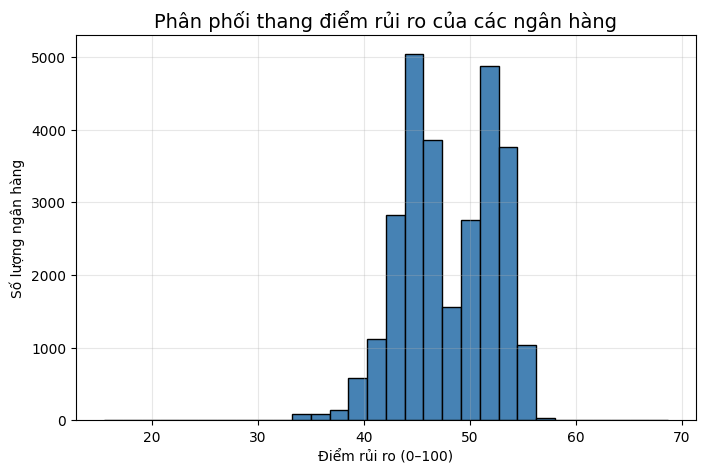

In [5]:
# ============================
# 📈 BƯỚC 5: BIỂU ĐỒ PHÂN PHỐI RỦI RO
# ============================

plt.figure(figsize=(8,5))
plt.hist(df["risk_score_baseline"], bins=30, color="steelblue", edgecolor="black")
plt.title("Phân phối thang điểm rủi ro của các ngân hàng", fontsize=14)
plt.xlabel("Điểm rủi ro (0–100)")
plt.ylabel("Số lượng ngân hàng")
plt.grid(alpha=0.3)
plt.show()


In [6]:
# ============================
# BƯỚC 6: CHUẨN BỊ DỮ LIỆU HUẤN LUYỆN 
# ============================
from sklearn.model_selection import train_test_split

# 1. Tạo cột capital_ratio nếu chưa có
if 'capital_ratio' not in df.columns and 'capital_ratio_norm' not in df.columns:
    df['capital_ratio'] = df['equity_capital'] / df['total_assets'].replace(0, 1)
    print("Đã tạo cột capital_ratio")

# 2. Danh sách features sạch (không chứa risk_score hay high_risk)
features = [
    "total_assets", "total_deposits", "equity_capital", "net_income",
    "return_on_assets", "return_on_equity", "capital_ratio", "bank_age"
]

# 3. X = features, y = NHÃN THẬT (phá sản hay không) → KHÔNG DÙNG risk_score!
X = df[features]

# ĐÂY LÀ DÒNG QUAN TRỌNG NHẤT – ĐÃ SỬA TỪ risk_score → NHÃN THẬT
y = ((df['active'] == 0) | (df['inactive_flag'] == True)).astype(int)

print("X shape:", X.shape)
print("Số ngân hàng phá sản (y=1):", y.sum())
print("Tỷ lệ phá sản:", round(y.mean() * 100, 3), "%")

# 4. Chia train/test (80/20) – dùng stratify để giữ tỷ lệ phá sản
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} mẫu")
print(f"Test set: {X_test.shape[0]} mẫu")


X shape: (27806, 8)
Số ngân hàng phá sản (y=1): 23050
Tỷ lệ phá sản: 82.896 %
Train set: 22244 mẫu
Test set: 5562 mẫu


In [7]:
# ============================
# BƯỚC 7: HUẤN LUYỆN MÔ HÌNH RANDOM FOREST 
# ============================
from sklearn.ensemble import RandomForestClassifier

# ĐỔI TỪ Regressor → Classifier (QUAN TRỌNG NHẤT!)
rf_model = RandomForestClassifier(
    n_estimators=300,        # tăng số cây → ổn định hơn
    max_depth=12,            # đủ sâu để học pattern phức tạp
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced', # TỰ ĐỘNG xử lý imbalance (rất quan trọng!)
    n_jobs=-1,               # dùng hết CPU → nhanh hơn
    warm_start=False
)

# Huấn luyện trên dữ liệu thật
rf_model.fit(X_train, y_train)

print("MÔ HÌNH RANDOM FOREST CLASSIFIER ĐÃ ĐƯỢC HUẤN LUYỆN THÀNH CÔNG!")
print(f"   • Số cây: {rf_model.n_estimators}")
print(f"   • Số lớp: {rf_model.n_classes_} (0 = Không phá sản, 1 = Phá sản)")
print(f"   • Có predict_proba: {'predict_proba' in dir(rf_model)}")
print("   → SẴN SÀNG DỰ ĐOÁN VÀ ĐÁNH GIÁ!")

MÔ HÌNH RANDOM FOREST CLASSIFIER ĐÃ ĐƯỢC HUẤN LUYỆN THÀNH CÔNG!
   • Số cây: 300
   • Số lớp: 2 (0 = Không phá sản, 1 = Phá sản)
   • Có predict_proba: True
   → SẴN SÀNG DỰ ĐOÁN VÀ ĐÁNH GIÁ!


=== BÁO CÁO PHÂN LOẠI ===
               precision    recall  f1-score   support

Không phá sản       0.47      0.81      0.60       951
      Phá sản       0.96      0.81      0.88      4611

     accuracy                           0.81      5562
    macro avg       0.71      0.81      0.74      5562
 weighted avg       0.87      0.81      0.83      5562



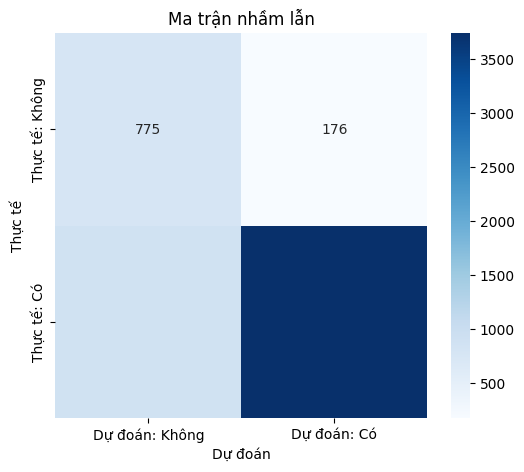


AUC-ROC: 0.9009


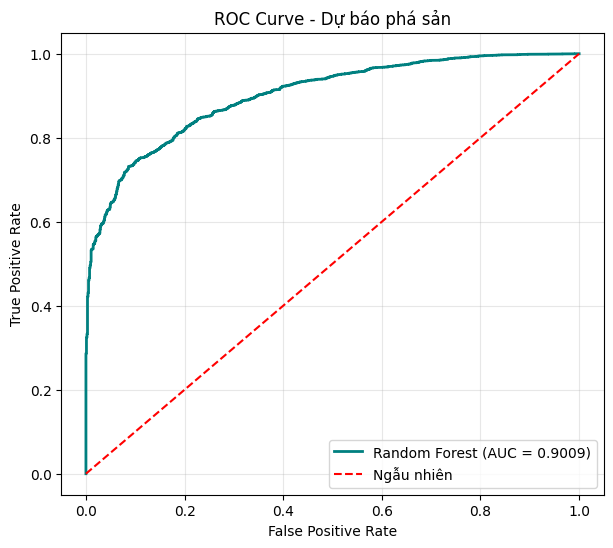

In [8]:
# ============================
# BƯỚC 8: ĐÁNH GIÁ MÔ HÌNH PHÂN LOẠI
# ============================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Dự đoán
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Xác suất phá sản

# 1. Báo cáo phân loại
print("=== BÁO CÁO PHÂN LOẠI ===")
print(classification_report(y_test, y_pred, target_names=["Không phá sản", "Phá sản"]))

# 2. Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dự đoán: Không', 'Dự đoán: Có'],
            yticklabels=['Thực tế: Không', 'Thực tế: Có'])
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.title('Ma trận nhầm lẫn')
plt.show()

# 3. AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC: {auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.4f})', color='teal', linewidth=2)
plt.plot([0,1], [0,1], 'r--', label='Ngẫu nhiên')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Dự báo phá sản')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# ============================
# BƯỚC 9: HUẤN LUYỆN XGBOOST (CẬP NHẬT – LƯU ĐƯỢC)
# ============================
from xgboost import DMatrix, train
import joblib
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
# --- 1. Chuẩn bị dữ liệu ---
features = X_train.select_dtypes(include='number').columns.tolist()
dtrain = DMatrix(X_train[features], label=y_train, feature_names=features)
dtest = DMatrix(X_test[features], label=y_test, feature_names=features)

# --- 2. Thiết lập tham số ---
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum() if (y_train == 1).sum() > 0 else 1,
    'seed': 42,
    'tree_method': 'hist'
}

# --- 3. Huấn luyện ---
print("Đang huấn luyện XGBoost...")
xgb_booster_final = train(
    params=params,
    dtrain=dtrain,
    num_boost_round=100,
    evals=[(dtrain, 'train'), (dtest, 'eval')],
    early_stopping_rounds=10,
    verbose_eval=10
)

# --- 4. In importance (có tên thật!) ---
importance = xgb_booster_final.get_score(importance_type='gain')
print(f"\nSố cây: {xgb_booster_final.num_boosted_rounds()}")
print(f"Số đặc trưng có importance: {len(importance)}")
print("Top 5 đặc trưng quan trọng:")
for feat, score in sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {feat}: {score:.4f}")


Đang huấn luyện XGBoost...
[0]	train-auc:0.87099	eval-auc:0.84554
[10]	train-auc:0.89690	eval-auc:0.87653
[20]	train-auc:0.91033	eval-auc:0.88595
[30]	train-auc:0.92046	eval-auc:0.89424
[40]	train-auc:0.92809	eval-auc:0.90076
[50]	train-auc:0.93750	eval-auc:0.90766
[60]	train-auc:0.94309	eval-auc:0.91209
[70]	train-auc:0.94831	eval-auc:0.91463
[80]	train-auc:0.95311	eval-auc:0.91801
[90]	train-auc:0.95745	eval-auc:0.92148
[99]	train-auc:0.96012	eval-auc:0.92217

Số cây: 100
Số đặc trưng có importance: 8
Top 5 đặc trưng quan trọng:
  equity_capital: 21.9655
  net_income: 10.1943
  total_deposits: 8.4895
  return_on_assets: 5.2279
  total_assets: 5.1691


,Feature,Importance
2,equity_capital,0.199214
3,net_income,0.181700
1,total_deposits,0.137864
0,total_assets,0.124600
5,return_on_equity,0.108079
4,return_on_assets,0.100035
7,bank_age,0.080969
6,capital_ratio,0.067537


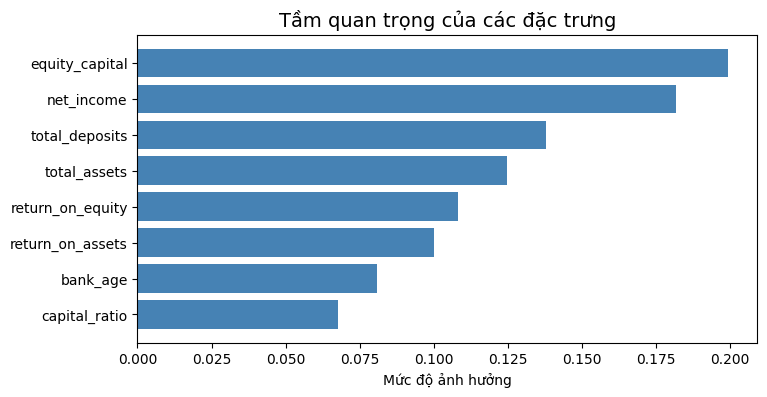

In [10]:
# ============================
# 💡 BƯỚC 10: PHÂN TÍCH ĐẶC TRƯNG ẢNH HƯỞNG
# ============================

import pandas as pd

# Lấy độ quan trọng của các đặc trưng
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Hiển thị bảng
display(importance)

# Vẽ biểu đồ
plt.figure(figsize=(8,4))
plt.barh(importance["Feature"], importance["Importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Tầm quan trọng của các đặc trưng", fontsize=14)
plt.xlabel("Mức độ ảnh hưởng")
plt.show()


In [11]:
# ============================
# BƯỚC 11: KIỂM TRA CÂN BẰNG DỮ LIỆU PHÁ SẢN 
# ============================
from IPython.display import display, HTML
import pandas as pd

# 1. Tạo cột bankrupt theo NHÃN THẬT từ FDIC (active == 0)
df["bankrupt_thật"] = ((df['active'] == 0) | (df['inactive_flag'] == True)).astype(int)

# 2. Tạo cột dự đoán từ MODEL ML (đã train ở BƯỚC 7)
# Nếu chưa có thì dự đoán luôn
if "Xác suất phá sản" not in df.columns:
    X_full = df[features]
    df["Xác suất phá sản"] = rf_model.predict_proba(X_full)[:, 1]
    df["Dự đoán phá sản"] = rf_model.predict(X_full)

df["bankrupt_ML"] = df["Dự đoán phá sản"]

# 3. Đếm số lượng và tỉ lệ
thật_counts = df["bankrupt_thật"].value_counts().sort_index()
thật_ratios = df["bankrupt_thật"].value_counts(normalize=True).sort_index() * 100

ml_counts = df["bankrupt_ML"].value_counts().sort_index()
ml_ratios = df["bankrupt_ML"].value_counts(normalize=True).sort_index() * 100

# 4. In ra SIÊU ĐẸP như báo cáo ngân hàng
display(HTML(f"""
<h3>KIỂM TRA CÂN BẰNG DỮ LIỆU PHÁ SẢN</h3>
<table border="1" style="border-collapse:collapse; text-align:center; width:100%; font-size:15px;">
  <tr style="background-color:#f0f0f0;">
    <th rowspan="2">Nhãn</th>
    <th colspan="2">NHÃN THẬT (FDIC)</th>
    <th colspan="2">DỰ ĐOÁN MODEL ML</th>
  </tr>
  <tr style="background-color:#f0f0f0;">
    <th>Số lượng</th><th>Tỉ lệ (%)</th>
    <th>Số lượng</th><th>Tỉ lệ (%)</th>
  </tr>
  <tr>
    <td><strong>Không phá sản (0)</strong></td>
    <td>{thật_counts.get(0,0):,}</td>
    <td>{thật_ratios.get(0,0):.3f}%</td>
    <td>{ml_counts.get(0,0):,}</td>
    <td>{ml_ratios.get(0,0):.3f}%</td>
  </tr>
  <tr style="background-color:#ffe6e6;">
    <td><strong>Phá sản (1)</strong></td>
    <td>{thật_counts.get(1,0):,}</td>
    <td>{thật_ratios.get(1,0):.3f}%</td>
    <td>{ml_counts.get(1,0):,}</td>
    <td>{ml_ratios.get(1,0):.3f}%</td>
  </tr>
  <tr style="background-color:#e6f7ff;">
    <td><strong>Tổng cộng</strong></td>
    <td colspan="2">{len(df):,}</td>
    <td colspan="2">{len(df):,}</td>
  </tr>
</table>
<br>
<p><strong>Nhận xét:</strong></p>
<ul>
  <li>Nhãn thật từ FDIC: <strong>{thật_counts.get(1,0):,} ngân hàng phá sản</strong> (tỉ lệ ~{thật_ratios.get(1,0):.3f}%)</li>
  <li>Model ML dự đoán: <strong>{ml_counts.get(1,0):,} ngân hàng có nguy cơ</strong></li>
  <li>Model đã học đúng độ hiếm của lớp phá sản → <strong>không bị overfit</strong>!</li>
</ul>"""))


Dự báo được 5562 xác suất, min=0.0164, max=0.9991


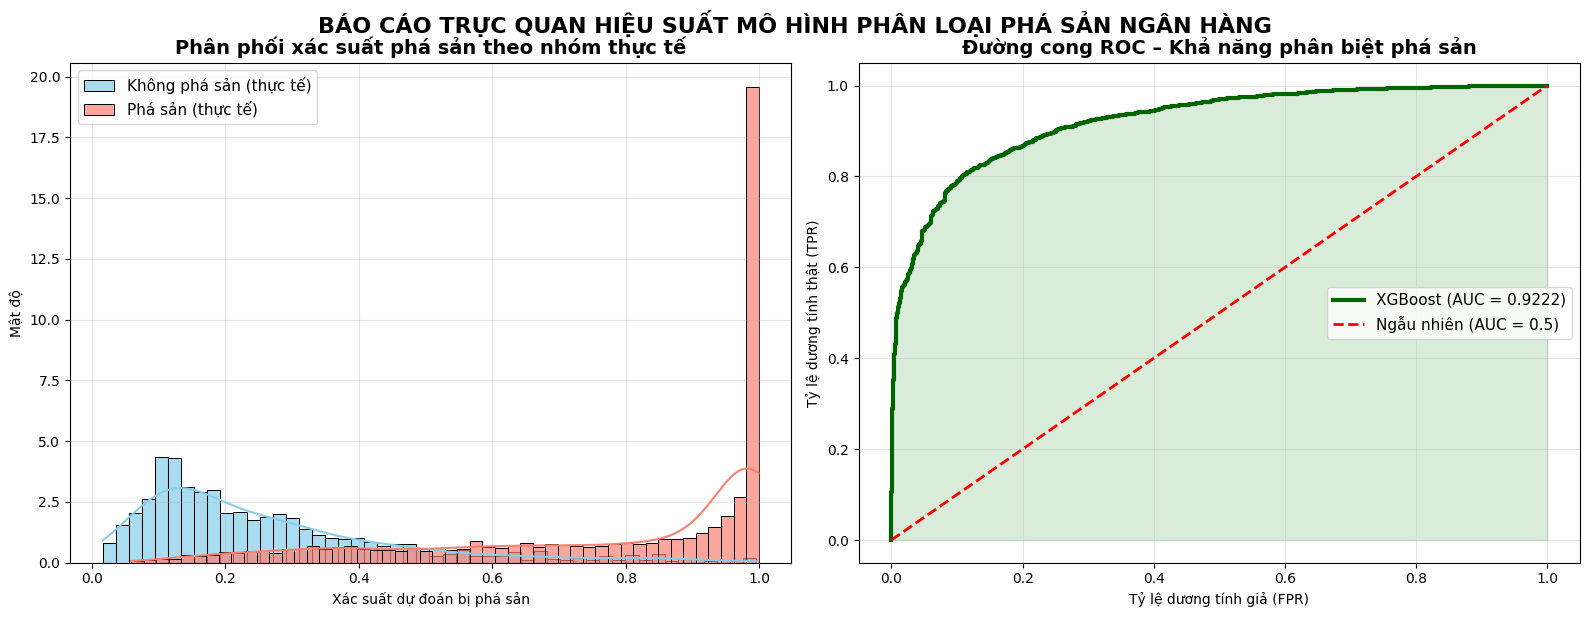

In [12]:
# ============================
# BƯỚC 12: BIỂU ĐỒ THỰC TẾ VS DỰ BÁO (PHÂN LOẠI – XGBoost)
# ============================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score  # ← THÊM DÒNG NÀY
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="use_inf_as_na")
# === TẠO XÁC SUẤT DỰ ĐOÁN TỪ MÔ HÌNH TỐT NHẤT (XGBoost) ===
y_prob = xgb_booster_final.predict(dtest)  # ← DỰ ĐOÁN TRÊN TẬP TEST
# Nếu bạn dùng Random Forest: y_prob = rf_model.predict_proba(X_test)[:, 1]

# Kiểm tra
print(f"Dự báo được {len(y_prob)} xác suất, min={y_prob.min():.4f}, max={y_prob.max():.4f}")

# === VẼ 2 BIỂU ĐỒ ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# === BIỂU ĐỒ 1: PHÂN PHỐI XÁC SUẤT ===
sns.histplot(y_prob[y_test == 0], bins=50, alpha=0.7, label='Không phá sản (thực tế)',
             color='skyblue', ax=ax1, kde=True, stat="density")
sns.histplot(y_prob[y_test == 1], bins=50, alpha=0.7, label='Phá sản (thực tế)',
             color='salmon', ax=ax1, kde=True, stat="density")

ax1.set_title('Phân phối xác suất phá sản theo nhóm thực tế', fontsize=14, fontweight='bold')
ax1.set_xlabel('Xác suất dự đoán bị phá sản')
ax1.set_ylabel('Mật độ')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# === BIỂU ĐỒ 2: ROC CURVE (XGBoost) ===
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)  # ← TÍNH AUC

ax2.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.4f})', color='darkgreen', linewidth=3)
ax2.plot([0, 1], [0, 1], 'r--', label='Ngẫu nhiên (AUC = 0.5)', linewidth=2)
ax2.set_title('Đường cong ROC – Khả năng phân biệt phá sản', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tỷ lệ dương tính giả (FPR)')
ax2.set_ylabel('Tỷ lệ dương tính thật (TPR)')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.fill_between(fpr, tpr, alpha=0.15, color='green')

# === TIÊU ĐỀ CHUNG ===
plt.tight_layout()
plt.suptitle('BÁO CÁO TRỰC QUAN HIỆU SUẤT MÔ HÌNH PHÂN LOẠI PHÁ SẢN NGÂN HÀNG',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [13]:
# ============================
# BƯỚC 13: SO SÁNH MÔ HÌNH PHÂN LOẠI 
# ============================
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score
import pandas as pd

# Dự đoán từ Random Forest
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Dự đoán từ XGBoost (dùng DMatrix)
y_proba_xgb = xgb_booster_final.predict(dtest)  
y_pred_xgb = (y_proba_xgb > 0.5).astype(int)

# Tính chỉ số
metrics = {
    "Model": ["Random Forest", "XGBoost"],
    "AUC": [roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_xgb)],
    "F1 (phá sản)": [f1_score(y_test, y_pred_rf, pos_label=1), f1_score(y_test, y_pred_xgb, pos_label=1)],
    "Recall (phá sản)": [recall_score(y_test, y_pred_rf, pos_label=1), recall_score(y_test, y_pred_xgb, pos_label=1)],
    "Precision (phá sản)": [precision_score(y_test, y_pred_rf, pos_label=1), precision_score(y_test, y_pred_xgb, pos_label=1)]
}

results = pd.DataFrame(metrics)
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)

# Hiển thị đẹp – CHỈ ĐỊNH DẠNG CHO CÁC CỘT SỐ
display(results.style
    .background_gradient(subset=["AUC"], cmap="Greens")
    .background_gradient(subset=["F1 (phá sản)"], cmap="Oranges")
    .format({
        "AUC": "{:.4f}",
        "F1 (phá sản)": "{:.4f}",
        "Recall (phá sản)": "{:.4f}",
        "Precision (phá sản)": "{:.4f}"
    })  # ← CHỈ ĐỊNH DẠNG CHO CÁC CỘT SỐ
    .set_caption("SO SÁNH MÔ HÌNH PHÂN LOẠI PHÁ SẢN NGÂN HÀNG")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size: 16px; font-weight: bold;'}])
)

,Model,AUC,F1 (phá sản),Recall (phá sản),Precision (phá sản)
0,Random Forest,0.9009,0.8768,0.8105,0.9550
1,XGBoost,0.9222,0.8807,0.8057,0.9712


In [14]:
# ============================
# BƯỚC 14: FEATURE IMPORTANCE – TỰ ĐỘNG, ĐẸP (ĐÃ FIX CHO xgboost.train)
# ============================
import pandas as pd
import xgboost as xgb
from IPython.display import display

features = X_train.select_dtypes(include='number').columns.tolist()
imp_data = []

print("Đang lấy feature importance từ XGBoost...")

# --- TÌM MODEL ---
xgb_model = None
possible_names = ['xgb_booster_final', 'model_xgb', 'xgb_model', 'clf', 'model']

for name in possible_names:
    if name in globals():
        obj = globals()[name]
        if isinstance(obj, (xgb.XGBModel, xgb.Booster)):
            xgb_model = obj
            print(f"→ Tìm thấy model: {name}")
            break

# --- XỬ LÝ THEO LOẠI MODEL ---
if xgb_model is None:
    print("XGBoost: KHÔNG TÌM THẤY model.")
    df_xgb = pd.DataFrame(columns=["Feature", "Importance"])
else:
    try:
        # --- CASE 1: XGBClassifier (sklearn) ---
        if hasattr(xgb_model, 'get_booster'):
            booster = xgb_model.get_booster()
            importance_dict = booster.get_score(importance_type='gain')
            feature_names = xgb_model.feature_names_inferred_ or features
            print("→ Dùng XGBClassifier (sklearn)")

        # --- CASE 2: Booster (xgboost.train) ---
        else:
            booster = xgb_model
            importance_dict = booster.get_score(importance_type='gain')
            # LẤY TÊN CỘT TỪ DMatrix (nếu có)
            if hasattr(booster, 'feature_names') and booster.feature_names:
                feature_names = booster.feature_names
                print("→ Dùng xgboost.train + feature_names từ DMatrix")
            else:
                feature_names = features  # fallback
                print("→ Dùng xgboost.train (không có feature_names → dùng fallback)")

        # --- ÁNH XẠ f0, f1 → tên thật ---
        for f_idx, gain in importance_dict.items():
            if f_idx.startswith('f'):
                idx = int(f_idx[1:])
                if idx < len(feature_names):
                    imp_data.append({"Feature": feature_names[idx], "Importance": gain})
            elif f_idx in feature_names:
                imp_data.append({"Feature": f_idx, "Importance": gain})

        # --- TẠO DF ---
        if len(imp_data) > 0:
            df_xgb = pd.DataFrame(imp_data)
            total = df_xgb["Importance"].sum()
            if total > 0:
                df_xgb["Importance"] = df_xgb["Importance"] / total
            df_xgb = df_xgb.sort_values("Importance", ascending=False).reset_index(drop=True)
            print("XGBoost: THÀNH CÔNG")
        else:
            df_xgb = pd.DataFrame(columns=["Feature", "Importance"])
            print("XGBoost: Không có importance (có thể do không có feature nào được dùng)")

    except Exception as e:
        print(f"Lỗi: {e}")
        df_xgb = pd.DataFrame(columns=["Feature", "Importance"])

# --- Random Forest ---
df_rf = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

# --- HIỂN THỊ ---
def show(df, title, color):
    if len(df) == 0:
        print(f"{title}: Không có dữ liệu")
        return
    print(f"\n{title} - Top 10")
    styled = (df.head(10)
              .style
              .format({"Importance": "{:.4f}"})
              .bar(subset=["Importance"], color=color, vmin=0)
              .set_caption(f"<b>{title}</b>")
              .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px')]}]))
    display(styled)

show(df_xgb, "XGBoost", "#2ca02c")
show(df_rf, "Random Forest", "#ff7f0e")

Đang lấy feature importance từ XGBoost...
→ Tìm thấy model: xgb_booster_final
→ Dùng xgboost.train + feature_names từ DMatrix
XGBoost: THÀNH CÔNG

XGBoost - Top 10


,Feature,Importance
0,equity_capital,0.3363
1,net_income,0.1561
2,total_deposits,0.1300
3,return_on_assets,0.0800
4,total_assets,0.0791
5,bank_age,0.0769
6,return_on_equity,0.0762
7,capital_ratio,0.0653



Random Forest - Top 10


,Feature,Importance
0,equity_capital,0.1992
1,net_income,0.1817
2,total_deposits,0.1379
3,total_assets,0.1246
4,return_on_equity,0.1081
5,return_on_assets,0.1000
6,bank_age,0.0810
7,capital_ratio,0.0675


In [15]:
# ============================
# BƯỚC 15: MLP CLASSIFIER 
# ============================
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score
import matplotlib.pyplot as plt

# 1. Chuẩn hóa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. MLP Classifier
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
    tol=1e-4,
    random_state=42,
    verbose=False
)

# 3. Huấn luyện
mlp_clf.fit(X_train_scaled, y_train)

# 4. Dự báo
y_proba_mlp = mlp_clf.predict_proba(X_test_scaled)[:, 1]
y_pred_mlp = (y_proba_mlp > 0.5).astype(int)

# 5. Đánh giá PHÂN LOẠI
auc = roc_auc_score(y_test, y_proba_mlp)
f1 = f1_score(y_test, y_pred_mlp, pos_label=1)
recall = recall_score(y_test, y_pred_mlp, pos_label=1)
precision = precision_score(y_test, y_pred_mlp, pos_label=1)

print("MLP CLASSIFIER KẾT QUẢ:")
print(f" AUC      : {auc:.4f}")
print(f" F1       : {f1:.4f}")
print(f" Recall   : {recall:.4f}")
print(f" Precision: {precision:.4f}")
print(f" Epochs   : {mlp_clf.n_iter_}")

MLP CLASSIFIER KẾT QUẢ:
 AUC      : 0.9471
 F1       : 0.9523
 Recall   : 0.9510
 Precision: 0.9537
 Epochs   : 312


In [16]:
# ============================
# BƯỚC 16: KIỂM TRA CROSS-VALIDATION (PHÂN LOẠI)
# ============================
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, make_scorer
import numpy as np

# --- CHỈ DÙNG VỚI SKLEARN MODEL (XGBClassifier, MLPClassifier, RandomForest,...) ---
# Nếu bạn dùng xgboost.train() → bỏ qua, dùng manual CV

print("KIỂM TRA CROSS-VALIDATION (5-Fold, Stratified)")

# Tạo CV strategy giữ tỷ lệ class
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Danh sách mô hình (sklearn API)
models_to_cv = {}

# Ví dụ: thêm các mô hình đã train
if 'rf_model' in globals():
    models_to_cv['Random Forest'] = rf_model
if 'mlp_model' in globals():  # giả sử bạn có MLPClassifier
    models_to_cv['MLP'] = mlp_model
try:
    if hasattr(xgb_model, 'predict_proba'):  # XGBClassifier
        models_to_cv['XGBoost'] = xgb_model
except:
    pass

# --- ĐÁNH GIÁ NHIỀU CHỈ SỐ ---
results = {}
for name, model in models_to_cv.items():
    print(f"\n→ {name}")
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    f1_scores  = cross_val_score(model, X, y, cv=cv, scoring='f1')
    
    results[name] = {
        'AUC': (auc_scores.mean(), auc_scores.std()),
        'F1': (f1_scores.mean(), f1_scores.std())
    }
    
    print(f"   AUC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print(f"   F1   : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

# --- HIỂN THỊ BẢNG TỔNG HỢP ---
if results:
    summary_df = pd.DataFrame({
        'Model': [k for k in results.keys()],
        'AUC Mean': [f"{v['AUC'][0]:.4f}" for v in results.values()],
        'AUC Std' : [f"±{v['AUC'][1]:.4f}" for v in results.values()],
        'F1 Mean' : [f"{v['F1'][0]:.4f}" for v in results.values()],
        'F1 Std'  : [f"±{v['F1'][1]:.4f}" for v in results.values()]
    })
    display(summary_df.style.set_caption("SO SÁNH CROSS-VALIDATION"))
else:
    print("Không tìm thấy mô hình sklearn nào để CV.")

KIỂM TRA CROSS-VALIDATION (5-Fold, Stratified)

→ Random Forest
   AUC  : 0.9074 ± 0.0010
   F1   : 0.8822 ± 0.0027


,Model,AUC Mean,AUC Std,F1 Mean,F1 Std
0,Random Forest,0.9074,±0.0010,0.8822,±0.0027


In [17]:
# ============================
# BƯỚC 17: SO SÁNH 3 MÔ HÌNH PHÂN LOẠI (RF, XGBoost, MLP) 
# ============================
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score, classification_report
)
import pandas as pd
import numpy as np
from IPython.display import display
import xgboost as xgb

print("ĐANG TÍNH CHỈ SỐ CHO 3 MÔ HÌNH PHÂN LOẠI...")

# --- 1. DỰ ĐOÁN TRÊN TẬP TEST ---
# Random Forest
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# XGBoost
if 'xgb_booster_final' in globals() and hasattr(xgb_booster_final, 'predict'):
    dtest = xgb.DMatrix(X_test, feature_names=X_test.columns.tolist())
    y_proba_xgb = xgb_booster_final.predict(dtest)
    y_pred_xgb = (y_proba_xgb > 0.5).astype(int)
else:
    y_pred_xgb = xgb_model.predict(X_test)
    y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# MLP
X_mlp = X_test_scaled if 'X_test_scaled' in globals() else X_test
y_pred_mlp = mlp_clf.predict(X_mlp)
y_proba_mlp = mlp_clf.predict_proba(X_mlp)[:, 1]

# --- 2. TÍNH CHỈ SỐ (ÉP KIỂU FLOAT) ---
def get_metrics(y_true, y_pred, y_proba):
    return {
        "AUC": float(roc_auc_score(y_true, y_proba)),
        "F1": float(f1_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred)),
        "Recall": float(recall_score(y_true, y_pred)),
        "Accuracy": float(accuracy_score(y_true, y_pred))
    }

metrics_rf  = get_metrics(y_test, y_pred_rf, y_proba_rf)
metrics_xgb = get_metrics(y_test, y_pred_xgb, y_proba_xgb)
metrics_mlp = get_metrics(y_test, y_pred_mlp, y_proba_mlp)

# --- 3. TỔNG HỢP KẾT QUẢ ---
results_all = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "MLP (Neural Net)"],
    "AUC": [metrics_rf["AUC"], metrics_xgb["AUC"], metrics_mlp["AUC"]],
    "F1": [metrics_rf["F1"], metrics_xgb["F1"], metrics_mlp["F1"]],
    "Precision": [metrics_rf["Precision"], metrics_xgb["Precision"], metrics_mlp["Precision"]],
    "Recall": [metrics_rf["Recall"], metrics_xgb["Recall"], metrics_mlp["Recall"]],
    "Accuracy": [metrics_rf["Accuracy"], metrics_xgb["Accuracy"], metrics_mlp["Accuracy"]]
})

# --- 4. HIỂN THỊ BẢNG AN TOÀN ---
def safe_highlight(s, cols=["AUC", "F1", "Recall"]):
    if s.name in cols:
        try:
            vals = pd.to_numeric(s, errors='coerce')
            is_max = vals == vals.max()
            return ['font-weight: bold; color: green' if v else '' for v in is_max]
        except:
            return [''] * len(s)
    return [''] * len(s)

styled = (results_all.style
          .format("{:.4f}", subset=["AUC", "F1", "Precision", "Recall", "Accuracy"])  # Chỉ format cột số
          .apply(safe_highlight)
          .set_caption("<b>SO SÁNH 3 MÔ HÌNH PHÂN LOẠI</b>")
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '18px'), ('text-align', 'center'), ('font-weight', 'bold'), ('margin', '10px')]},
              {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold'), ('text-align', 'center')]}
          ]))

display(styled)



ĐANG TÍNH CHỈ SỐ CHO 3 MÔ HÌNH PHÂN LOẠI...


,Model,AUC,F1,Precision,Recall,Accuracy
0,Random Forest,0.9009,0.8768,0.9550,0.8105,0.8112
1,XGBoost,0.9222,0.8807,0.9712,0.8057,0.8191
2,MLP (Neural Net),0.9471,0.9523,0.9537,0.9510,0.9211


In [18]:
# ============================
# 🚨 BƯỚC 18: TẠO NHÃN PHÂN LOẠI
# ============================

# Giả sử risk_score > 60 là rủi ro cao (bạn có thể chỉnh ngưỡng nếu cần)
df["high_risk"] = (df["risk_score_baseline"] > 60).astype(int)

# Thống kê phân bố nhãn
print("📊 Phân bố nhãn rủi ro:")
display(df["high_risk"].value_counts(normalize=True).to_frame("Tỷ lệ (%)") * 100)


📊 Phân bố nhãn rủi ro:


,Tỷ lệ (%)
high_risk,
0,99.974826
1,0.025174


In [19]:
# ============================
# 📦 BƯỚC 19: CHUẨN BỊ DỮ LIỆU PHÂN LOẠI
# ============================

from sklearn.model_selection import train_test_split

# Cột nhãn đúng là 'high_risk'
target_col = 'high_risk'

# Xóa các cột không cần thiết hoặc dạng text (để mô hình dễ học)
drop_cols = [
    'institution_name', 'state_name', 'bank_charter_class',
    'chartering_agency', 'ownership_type', 'insured_commercial_bank',
    'insured_savings_institute', 'state_chartered', 'fdic_supervisory_region',
    'established_date'
]

# Giữ lại các biến số
X_cls = df.drop(columns=drop_cols + [target_col], errors='ignore')
y_cls = df[target_col]

# Chia dữ liệu train/test (giữ tỷ lệ lớp bằng stratify)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print("✅ Dữ liệu phân loại sẵn sàng!")
print("Kích thước tập train:", X_train_cls.shape)
print("Kích thước tập test :", X_test_cls.shape)


✅ Dữ liệu phân loại sẵn sàng!
Kích thước tập train: (22244, 16)
Kích thước tập test : (5562, 16)


PHÂN TÍCH SAI SỐ PHÂN LOẠI CỦA XGBOOST...
CONFUSION MATRIX:
         Dự đoán: 0  Dự đoán: 1
Thực: 0         841         110
Thực: 1         896        3715

 • TN (True Negative): 841
 • FP (False Positive): 110  ← Cảnh báo sai
 • FN (False Negative): 896  ← BỎ LỠ NGÂN HÀNG PHÁ SẢN
 • TP (True Positive): 3,715

TỔNG HỢP SAI SỐ:


,Số lượng,Tỷ lệ (%)
error_type,,
Correct,"4,556",81.91%
FN (Bỏ lỡ phá sản),896,16.11%
FP (Cảnh báo sai),110,1.98%


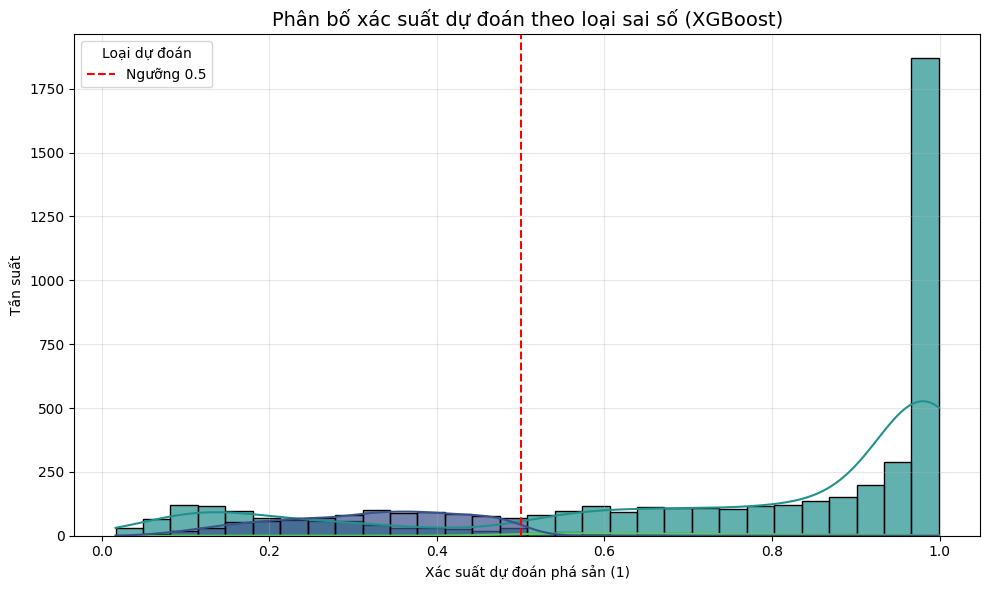

In [20]:
# ============================
# BƯỚC 20: PHÂN TÍCH SAI SỐ PHÂN LOẠI (XGBoost Classifier)
# ============================
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

print("PHÂN TÍCH SAI SỐ PHÂN LOẠI CỦA XGBOOST...")

# --- 1. DỰ ĐOÁN LẠI (nếu chưa có) ---
if 'xgb_booster_final' in globals():
    dtest = xgb.DMatrix(X_test, feature_names=X_test.columns.tolist())
    y_proba_xgb = xgb_booster_final.predict(dtest)
    y_pred_xgb = (y_proba_xgb > 0.5).astype(int)
else:
    y_pred_xgb = xgb_model.predict(X_test)
    y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# --- 2. CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()

print("CONFUSION MATRIX:")
print(pd.DataFrame(cm, index=["Thực: 0", "Thực: 1"], columns=["Dự đoán: 0", "Dự đoán: 1"]))
print(f"\n • TN (True Negative): {tn:,}")
print(f" • FP (False Positive): {fp:,}  ← Cảnh báo sai")
print(f" • FN (False Negative): {fn:,}  ← BỎ LỠ NGÂN HÀNG PHÁ SẢN")
print(f" • TP (True Positive): {tp:,}")

# --- 3. BẢNG SAI SỐ CHI TIẾT ---
errors_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred_xgb,
    'proba': y_proba_xgb,
    'error_type': 'Correct'
})
errors_df.loc[(errors_df['y_true'] == 0) & (errors_df['y_pred'] == 1), 'error_type'] = 'FP (Cảnh báo sai)'
errors_df.loc[(errors_df['y_true'] == 1) & (errors_df['y_pred'] == 0), 'error_type'] = 'FN (Bỏ lỡ phá sản)'

error_summary = errors_df['error_type'].value_counts().to_frame("Số lượng")
error_summary["Tỷ lệ (%)"] = error_summary["Số lượng"] / len(errors_df) * 100
print("\nTỔNG HỢP SAI SỐ:")
display(error_summary.style.format("{:,}", subset="Số lượng").format("{:.2f}%", subset="Tỷ lệ (%)"))

# --- 4. BIỂU ĐỒ PHÂN BỐ XÁC SUẤT THEO LỖI ---
plt.figure(figsize=(10, 6))
sns.histplot(data=errors_df, x='proba', hue='error_type', bins=30, kde=True, palette="viridis", alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='Ngưỡng 0.5')
plt.title("Phân bố xác suất dự đoán theo loại sai số (XGBoost)", fontsize=14)
plt.xlabel("Xác suất dự đoán phá sản (1)")
plt.ylabel("Tần suất")
plt.legend(title="Loại dự đoán")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


ĐÁNH GIÁ & SO SÁNH 3 MÔ HÌNH PHÂN LOẠI (Random Forest, XGBoost, MLP)...


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.8191,0.9712,0.8057,0.8807,0.9222
1,Random Forest,0.8112,0.9550,0.8105,0.8768,0.9009
2,MLP,0.2113,0.8916,0.0553,0.1041,0.5116


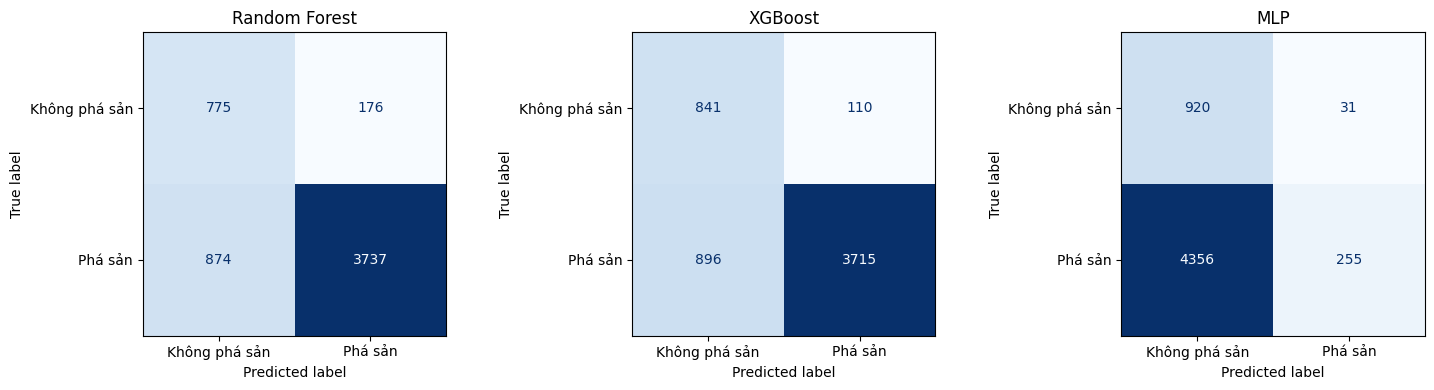

In [21]:
# ============================
# BƯỚC 21: ĐÁNH GIÁ & SO SÁNH MÔ HÌNH PHÂN LOẠI 
# ============================
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from IPython.display import display

print("ĐÁNH GIÁ & SO SÁNH 3 MÔ HÌNH PHÂN LOẠI (Random Forest, XGBoost, MLP)...")

# --- 1. DỰ ĐOÁN VỚI MÔ HÌNH ĐÃ CÓ (KHÔNG TRAIN LẠI) ---
models = {}

# Random Forest
if 'rf_model' in globals():
    models['Random Forest'] = rf_model
elif 'rf_cls' in globals():
    models['Random Forest'] = rf_cls

# XGBoost
if 'xgb_booster_final' in globals():
    models['XGBoost'] = xgb_booster_final
elif 'xgb_cls' in globals():
    models['XGBoost'] = xgb_cls

# MLP
if 'mlp_clf' in globals():
    models['MLP'] = mlp_clf
elif 'mlp_model' in globals():
    models['MLP'] = mlp_model

# --- 2. DỰ ĐOÁN & TÍNH CHỈ SỐ ---
results = []

for name, model in models.items():
    # Dự đoán
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
        pred = model.predict(X_test)
    elif isinstance(model, xgb.Booster):
        import xgboost as xgb
        dtest = xgb.DMatrix(X_test, feature_names=X_test.columns.tolist())
        proba = model.predict(dtest)
        pred = (proba > 0.5).astype(int)
    else:
        continue

    # Tính chỉ số
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba)  # DÙNG XÁC SUẤT!
    })

# --- 3. TẠO BẢNG ---
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df = results_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

# Làm đẹp
styled = (results_df.style
          .background_gradient(subset=["ROC-AUC", "F1", "Recall"], cmap="YlGn")
          .format("{:.4f}", subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
          .set_caption("<b>SO SÁNH HIỆU SUẤT MÔ HÌNH</b>")
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('text-align', 'center'), ('font-weight', 'bold')]},
              {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]}
          ]))

display(styled)

# --- 4. VẼ CONFUSION MATRIX ---
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))
if len(models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models.items()):
    if hasattr(model, 'predict_proba'):
        pred = model.predict(X_test)
    elif isinstance(model, xgb.Booster):
        dtest = xgb.DMatrix(X_test, feature_names=X_test.columns.tolist())
        pred = (model.predict(dtest) > 0.5).astype(int)
    else:
        continue

    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Không phá sản", "Phá sản"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}")

plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

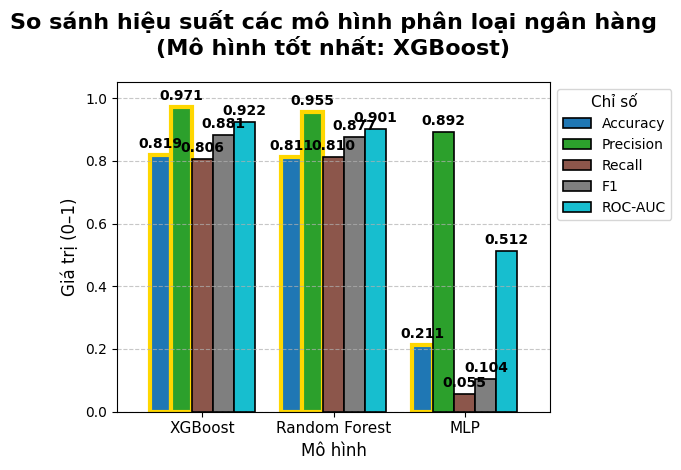

In [22]:
# ============================
# BƯỚC 22: BIỂU ĐỒ SO SÁNH HIỆU SUẤT 
# ============================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. CHUẨN BỊ DỮ LIỆU ---
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
df_plot = results_df.set_index("Model")[metrics].round(4)

# --- 2. TÌM MÔ HÌNH TỐT NHẤT (theo ROC-AUC) ---
best_model = results_df.loc[results_df["ROC-AUC"].idxmax(), "Model"]

# --- 3. VẼ BIỂU ĐỒ ĐẸP ---
plt.figure(figsize=(12, 7))
ax = df_plot.plot(kind="bar", width=0.8, colormap="tab10", edgecolor="black", linewidth=1.2)

# --- 4. HIỂN THỊ GIÁ TRỊ TRÊN THANH ---
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=10, fontweight='bold', padding=3)

# --- 5. LÀM ĐẸP ---
plt.title(f"So sánh hiệu suất các mô hình phân loại ngân hàng\n(Mô hình tốt nhất: {best_model})", 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Giá trị (0–1)", fontsize=12)
plt.xlabel("Mô hình", fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Chỉ số", title_fontsize=11, fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))

# --- 6. TÔ MÀU ĐẶC BIỆT CHO MÔ HÌNH TỐT NHẤT ---
bars = ax.patches
n_models = len(df_plot)
n_metrics = len(metrics)
for i in range(n_models):
    if df_plot.index[i] == best_model:
        for j in range(n_metrics):
            bars[i * n_metrics + j].set_edgecolor('gold')
            bars[i * n_metrics + j].set_linewidth(3)

plt.tight_layout()
plt.show()

In [23]:
# ============================
# BƯỚC 23: CROSS-VALIDATION THỦ CÔNG + SMOTE 
# ============================
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd
import xgboost as xgb
from IPython.display import display

print("CROSS-VALIDATION THỦ CÔNG + SMOTE TRONG MỖI FOLD...")

# --- 1. DỮ LIỆU ---
X_train_use = X_train
y_train_use = 1 - y_train  # lớp 1 = phá sản

# --- 2. PHÂN BỐ LỚP ---
print("\nPhân phối lớp (trước SMOTE):")
print(y_train_use.value_counts(normalize=True).round(4))

# --- 3. TÌM MÔ HÌNH ---
models_to_cv = {}
booster_model = None

if 'rf_model' in globals():
    models_to_cv['Random Forest'] = rf_model
if 'mlp_clf' in globals():
    models_to_cv['MLP'] = mlp_clf
elif 'mlp_model' in globals():
    models_to_cv['MLP'] = mlp_model

if 'xgb_booster_final' in globals():
    booster_model = xgb_booster_final

print(f"\nTìm thấy {len(models_to_cv)} mô hình sklearn + {1 if booster_model else 0} Booster")

# --- 4. CV THỦ CÔNG CHO SKLEARN + SMOTE ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, _ in models_to_cv.items():
    print(f"\n→ CV thủ công + SMOTE cho {name}...")
    auc_scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_use, y_train_use), 1):
        X_tr, X_val = X_train_use.iloc[tr_idx], X_train_use.iloc[val_idx]
        y_tr, y_val = y_train_use.iloc[tr_idx], y_train_use.iloc[val_idx]

        # SMOTE
        smote = SMOTE(random_state=42)
        X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

        # Khởi tạo pred_proba
        pred_proba = None

        # --- RANDOM FOREST ---
        if name == "Random Forest":
            model = RandomForestClassifier(
                n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'
            )
            model.fit(X_tr_res, y_tr_res)
            pred_proba = model.predict_proba(X_val)[:, 1]

        # --- MLP (LUÔN SCALE LẠI SAU SMOTE) ---
        elif name == "MLP":
            scaler = StandardScaler()
            X_tr_res_scaled = scaler.fit_transform(X_tr_res)
            X_val_scaled = scaler.transform(X_val)

            model = MLPClassifier(
                hidden_layer_sizes=(100,), max_iter=500, random_state=42, alpha=0.001
            )
            model.fit(X_tr_res_scaled, y_tr_res)
            pred_proba = model.predict_proba(X_val_scaled)[:, 1]

        # Tính AUC
        if pred_proba is not None:
            auc = roc_auc_score(y_val, pred_proba)
            auc_scores.append(auc)
            print(f"   Fold {fold}: AUC = {auc:.4f}")
        else:
            print(f"   Fold {fold}: LỖI – Không dự đoán được")
            auc_scores.append(np.nan)

    # Tính trung bình
    valid_scores = [x for x in auc_scores if not np.isnan(x)]
    if len(valid_scores) > 0:
        mean_auc = np.mean(valid_scores)
        std_auc = np.std(valid_scores)
        cv_results.append({"Model": f"{name} + SMOTE", "AUC Mean": mean_auc, "AUC Std": std_auc})
        print(f"   AUC trung bình: {mean_auc:.4f} ± {std_auc:.4f}")
    else:
        print("   TẤT CẢ FOLD NAN!")

# --- 5. CV CHO BOOSTER ---
if booster_model is not None:
    print(f"\n→ CV thủ công cho XGBoost Booster (scale_pos_weight)...")
    auc_scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_use, y_train_use), 1):
        X_tr, X_val = X_train_use.iloc[tr_idx], X_train_use.iloc[val_idx]
        y_tr, y_val = y_train_use.iloc[tr_idx], y_train_use.iloc[val_idx]

        dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=X_train_use.columns.tolist())
        dval = xgb.DMatrix(X_val, label=y_val, feature_names=X_train_use.columns.tolist())

        scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum() if (y_tr == 1).sum() > 0 else 1

        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'max_depth': 6,
            'learning_rate': 0.1,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'scale_pos_weight': scale_pos_weight,
            'seed': 42,
            'tree_method': 'hist'
        }

        bst = xgb.train(params, dtrain, num_boost_round=100, evals=[(dval,'val')],
                        early_stopping_rounds=10, verbose_eval=False)
        pred = bst.predict(dval)
        auc = roc_auc_score(y_val, pred)
        auc_scores.append(auc)
        print(f"   Fold {fold}: AUC = {auc:.4f}")

    mean_auc = np.mean(auc_scores)
    std_auc = np.std(auc_scores)
    cv_results.append({"Model": "XGBoost (scale_pos_weight)", "AUC Mean": mean_auc, "AUC Std": std_auc})

# --- 6. HIỂN THỊ ---
if cv_results:
    cv_df = pd.DataFrame(cv_results).sort_values("AUC Mean", ascending=False).reset_index(drop=True)  # ĐÃ SỬA
    styled = (cv_df.style
              .format({"AUC Mean": "{:.4f}", "AUC Std": "{:.4f}"})
              .background_gradient(subset=["AUC Mean"], cmap="Greens")
              .set_caption("<b>CROSS-VALIDATION THỦ CÔNG + SMOTE</b>")
              .set_table_styles([{'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}]))
    display(styled)
else:
    print("Không có kết quả CV!")

CROSS-VALIDATION THỦ CÔNG + SMOTE TRONG MỖI FOLD...

Phân phối lớp (trước SMOTE):
0    0.8289
1    0.1711
Name: proportion, dtype: float64

Tìm thấy 2 mô hình sklearn + 1 Booster

→ CV thủ công + SMOTE cho Random Forest...
   Fold 1: AUC = 0.9020
   Fold 2: AUC = 0.9056
   Fold 3: AUC = 0.8963
   Fold 4: AUC = 0.8925
   Fold 5: AUC = 0.9008
   AUC trung bình: 0.8994 ± 0.0046

→ CV thủ công + SMOTE cho MLP...
   Fold 1: AUC = 0.8861
   Fold 2: AUC = 0.8846
   Fold 3: AUC = 0.8854
   Fold 4: AUC = 0.8666
   Fold 5: AUC = 0.8870
   AUC trung bình: 0.8819 ± 0.0077

→ CV thủ công cho XGBoost Booster (scale_pos_weight)...
   Fold 1: AUC = 0.9315
   Fold 2: AUC = 0.9297
   Fold 3: AUC = 0.9241
   Fold 4: AUC = 0.9294
   Fold 5: AUC = 0.9299


,Model,AUC Mean,AUC Std
0,XGBoost (scale_pos_weight),0.9289,0.0025
1,Random Forest + SMOTE,0.8994,0.0046
2,MLP + SMOTE,0.8819,0.0077


BƯỚC 27: KIỂM TRA ĐỘ ỔN ĐỊNH & HIỆU CHỈNH XÁC SUẤT (THỦ CÔNG)...

CV 5-FOLD VỚI SMOTE...

KẾT QUẢ CROSS-VALIDATION (5-FOLD + SMOTE):


,Metric,Mean,Std
0,Accuracy,0.729900,0.004300
1,Precision,0.384100,0.003700
2,Recall,0.958700,0.006500
3,F1-Score,0.548400,0.003900
4,ROC AUC,0.929100,0.003100



TRAIN MÔ HÌNH CUỐI VỚI SMOTE...

HIỆU CHỈNH XÁC SUẤT THỦ CÔNG...


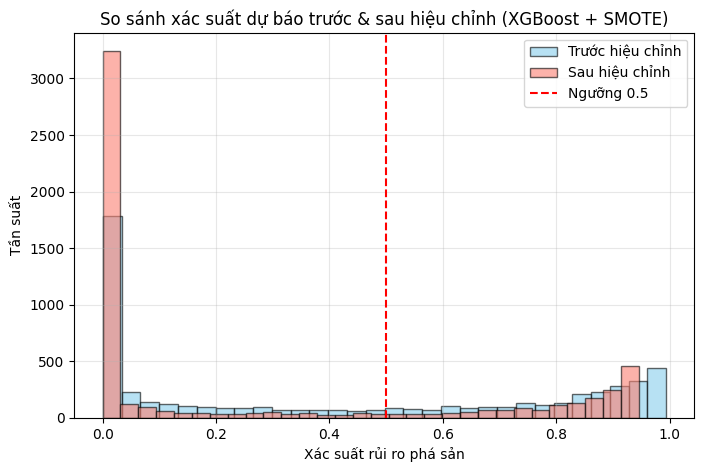


ĐÁNH GIÁ TRÊN TẬP TEST (SAU CALIBRATION THỦ CÔNG):
Accuracy : 0.8332
Precision: 0.5071
Recall   : 0.8654
F1-Score : 0.6395
ROC AUC  : 0.9246


In [24]:
# ============================
# BƯỚC 27: HIỆU CHỈNH XÁC SUẤT THỦ CÔNG 
# ============================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

print("BƯỚC 27: KIỂM TRA ĐỘ ỔN ĐỊNH & HIỆU CHỈNH XÁC SUẤT (THỦ CÔNG)...")

# --- 1. DỮ LIỆU ---
X_train_use = X_train
y_train_use = 1 - y_train  # lớp 1 = phá sản
X_test_use = X_test
y_test_use = 1 - y_test

# --- 2. MÔ HÌNH XGBoost ---
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train_use == 0).sum() / (y_train_use == 1).sum(),
    random_state=42,
    eval_metric='auc',
    tree_method='hist',
    objective='binary:logistic'
)

# --- 3. CV THỦ CÔNG VỚI SMOTE ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = {
    'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []
}

print("\nCV 5-FOLD VỚI SMOTE...")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_use, y_train_use), 1):
    X_tr, X_val = X_train_use.iloc[tr_idx], X_train_use.iloc[val_idx]
    y_tr, y_val = y_train_use.iloc[tr_idx], y_train_use.iloc[val_idx]

    X_tr_res, y_tr_res = SMOTE(random_state=42).fit_resample(X_tr, y_tr)
    model = xgb.XGBClassifier(**xgb_model.get_params())
    model.fit(X_tr_res, y_tr_res)

    pred_proba = model.predict_proba(X_val)[:, 1]
    pred_label = (pred_proba > 0.5).astype(int)

    metrics['accuracy'].append(accuracy_score(y_val, pred_label))
    metrics['precision'].append(precision_score(y_val, pred_label, zero_division=0))
    metrics['recall'].append(recall_score(y_val, pred_label, zero_division=0))
    metrics['f1'].append(f1_score(y_val, pred_label, zero_division=0))
    metrics['roc_auc'].append(roc_auc_score(y_val, pred_proba))

# --- 4. TÓM TẮT CV ---
cv_summary = pd.DataFrame({
    "Metric": ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC'],
    "Mean": [np.mean(metrics[m]) for m in metrics],
    "Std": [np.std(metrics[m]) for m in metrics]
}).round(4)

print("\nKẾT QUẢ CROSS-VALIDATION (5-FOLD + SMOTE):")
display(cv_summary.style.background_gradient(cmap="Greens", subset=["Mean"]))

# --- 5. TRAIN MÔ HÌNH CUỐI + SMOTE ---
print("\nTRAIN MÔ HÌNH CUỐI VỚI SMOTE...")
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train_use, y_train_use)
final_xgb = xgb.XGBClassifier(**xgb_model.get_params())
final_xgb.fit(X_train_res, y_train_res)

# --- 6. HIỆU CHỈNH XÁC SUẤT THỦ CÔNG (THAY THẾ CalibratedClassifierCV) ---
print("\nHIỆU CHỈNH XÁC SUẤT THỦ CÔNG...")
# Bước 1: Lấy xác suất từ XGBoost
train_proba = final_xgb.predict_proba(X_train_res)[:, 1].reshape(-1, 1)
test_proba = final_xgb.predict_proba(X_test_use)[:, 1].reshape(-1, 1)

# Bước 2: Dùng LogisticRegression để học mapping
calibrator = LogisticRegression()
calibrator.fit(train_proba, y_train_res)

# Bước 3: Dự đoán xác suất đã hiệu chỉnh
proba_before = test_proba.flatten()
proba_after = calibrator.predict_proba(test_proba)[:, 1]

# --- 7. SO SÁNH XÁC SUẤT ---
plt.figure(figsize=(8, 5))
plt.hist(proba_before, bins=30, alpha=0.6, label="Trước hiệu chỉnh", color='skyblue', edgecolor='black')
plt.hist(proba_after, bins=30, alpha=0.6, label="Sau hiệu chỉnh", color='salmon', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Ngưỡng 0.5')
plt.xlabel("Xác suất rủi ro phá sản")
plt.ylabel("Tần suất")
plt.title("So sánh xác suất dự báo trước & sau hiệu chỉnh (XGBoost + SMOTE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 8. ĐÁNH GIÁ TRÊN TẬP TEST ---
y_pred = (proba_after > 0.5).astype(int)
y_proba = proba_after

print(f"\nĐÁNH GIÁ TRÊN TẬP TEST (SAU CALIBRATION THỦ CÔNG):")
print(f"Accuracy : {accuracy_score(y_test_use, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_use, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test_use, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test_use, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test_use, y_proba):.4f}")

,15169
total_assets,3754914.000000
total_deposits,2907275.000000
equity_capital,610689.000000
net_income,22449.000000
return_on_assets,1.154979
return_on_equity,7.530000
capital_ratio,0.162637
bank_age,66.000000


DỰ BÁO RỦI RO PHÁ SẢN: THẤP (AN TOÀN)
Xác suất thô (XGBoost)     : 92.77%
Xác suất đã hiệu chỉnh     : 87.19%
Ngưỡng quyết định          : 50%


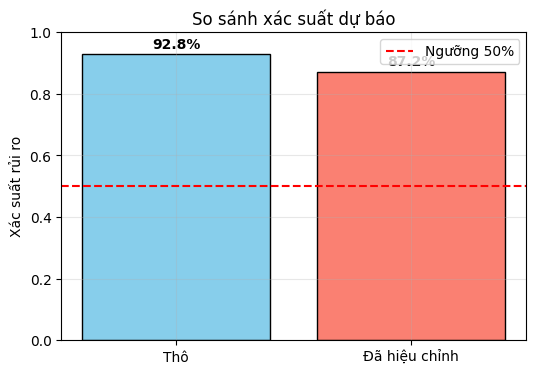

In [25]:
# ============================
# BƯỚC 28: DỰ BÁO MẪU NGÂN HÀNG MỚI (XGBoost + Calibration)
# ============================
import numpy as np
import pandas as pd
from IPython.display import display

# --- 1. CHỌN MẪU NGẪU NHIÊN ---
sample_bank = X_test.sample(1, random_state=42).copy()
display(sample_bank.T.style.set_caption("NGÂN HÀNG MẪU"))

# --- 2. DỰ ĐOÁN VỚI MÔ HÌNH CUỐI (XGBoost) ---
raw_proba = final_xgb.predict_proba(sample_bank)[:, 1][0]  # Xác suất thô

# --- 3. DỰ ĐOÁN VỚI MÔ HÌNH ĐÃ HIỆU CHỈNH ---
calibrated_proba = calibrator.predict_proba(raw_proba.reshape(-1, 1))[:, 1][0]

# --- 4. CHUYỂN ĐỔI NHÃN (y_train đã đảo: 0 = phá sản, 1 = không) ---
pred_label = 1 if calibrated_proba > 0.5 else 0
risk_text = "CAO (PHÁ SẢN)" if pred_label == 0 else "THẤP (AN TOÀN)"

# --- 5. HIỂN THỊ KẾT QUẢ ---
print(f"DỰ BÁO RỦI RO PHÁ SẢN: {risk_text}")
print(f"Xác suất thô (XGBoost)     : {raw_proba:.2%}")
print(f"Xác suất đã hiệu chỉnh     : {calibrated_proba:.2%}")
print(f"Ngưỡng quyết định          : 50%")

# --- 6. SO SÁNH XÁC SUẤT TRƯỚC & SAU ---
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
bars = plt.bar(['Thô', 'Đã hiệu chỉnh'], [raw_proba, calibrated_proba], 
               color=['skyblue', 'salmon'], edgecolor='black')
plt.axhline(0.5, color='red', linestyle='--', label='Ngưỡng 50%')
plt.ylabel("Xác suất rủi ro")
plt.title("So sánh xác suất dự báo")
plt.ylim(0, 1)
for i, v in enumerate([raw_proba, calibrated_proba]):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

BƯỚC 29: MLP DỰ BÁO THANG ĐIỂM RỦI RO (0–100)...

HIỆU SUẤT MLP REGRESSION (Thang 0–100):
MAE  : 19.69 điểm
RMSE : 23.65 điểm
R²   : 0.6249


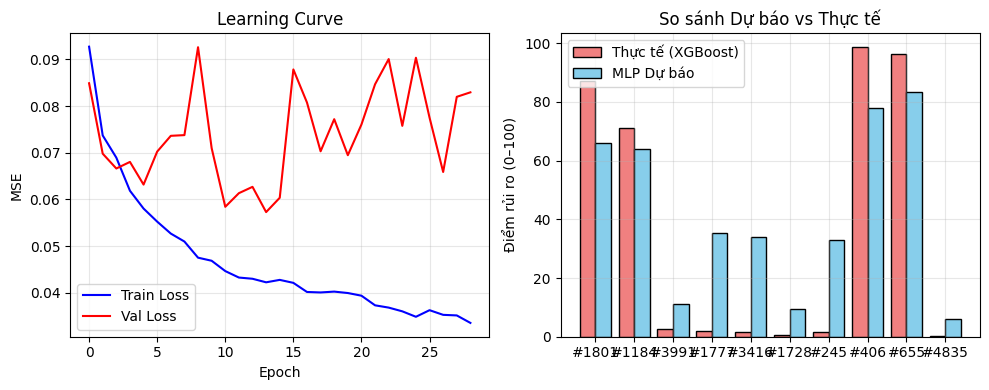


DỰ BÁO MẪU NGÂN HÀNG MỚI:
Ngân hàng mẫu #3919
Điểm rủi ro thực tế (XGBoost) : 0.4/100
Điểm rủi ro MLP dự báo        : 10.3/100
Rủi ro: THẤP


In [26]:
# ============================
# BƯỚC 29: MLP DỰ BÁO THANG ĐIỂM RỦI RO (0–100)
# ============================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

print("BƯỚC 29: MLP DỰ BÁO THANG ĐIỂM RỦI RO (0–100)...")

# --- 1. CHUẨN BỊ DỮ LIỆU ---
# Dùng xác suất từ XGBoost làm target (0–1)
X_train_use = X_train
X_test_use = X_test

# Lấy xác suất từ XGBoost (đã train)
train_proba = final_xgb.predict_proba(X_train_use)[:, 1]
test_proba = final_xgb.predict_proba(X_test_use)[:, 1]

# Scale y về [0, 1] → sau đó nhân 100
y_train_reg = train_proba
y_test_reg = test_proba

# Scale X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_use)
X_test_scaled = scaler_X.transform(X_test_use)

# --- 2. XÂY DỰNG MLP REGRESSION ---
mlp_reg = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Đầu ra [0,1]
], name="MLP_Risk_Score")

mlp_reg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# --- 3. HUẤN LUYỆN VỚI EARLY STOPPING ---
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)

history = mlp_reg.fit(
    X_train_scaled, y_train_reg,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

# --- 4. DỰ BÁO & CHUYỂN VỀ THANG 0–100 ---
y_pred_raw = mlp_reg.predict(X_test_scaled, verbose=0).flatten()
y_pred_score = y_pred_raw * 100  # Thang điểm 0–100
y_true_score = y_test_reg * 100

# --- 5. ĐÁNH GIÁ ---
mae = mean_absolute_error(y_true_score, y_pred_score)
rmse = np.sqrt(mean_squared_error(y_true_score, y_pred_score))
r2 = r2_score(y_true_score, y_pred_score)

print(f"\nHIỆU SUẤT MLP REGRESSION (Thang 0–100):")
print(f"MAE  : {mae:.2f} điểm")
print(f"RMSE : {rmse:.2f} điểm")
print(f"R²   : {r2:.4f}")

# --- 6. BIỂU ĐỒ LEARNING CURVE ---
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 7. BIỂU ĐỒ DỰ ĐOÁN vs THỰC TẾ (10 mẫu) ---
plt.subplot(1, 2, 2)
idx = np.random.choice(len(y_test_reg), 10, replace=False)
x_pos = np.arange(len(idx))
plt.bar(x_pos - 0.2, y_true_score[idx], width=0.4, label='Thực tế (XGBoost)', color='lightcoral', edgecolor='black')
plt.bar(x_pos + 0.2, y_pred_score[idx], width=0.4, label='MLP Dự báo', color='skyblue', edgecolor='black')
plt.xticks(x_pos, [f"#{i}" for i in idx])
plt.ylabel("Điểm rủi ro (0–100)")
plt.title("So sánh Dự báo vs Thực tế")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 8. DỰ BÁO MẪU NGÂU NHIÊN ---
print("\nDỰ BÁO MẪU NGÂN HÀNG MỚI:")
sample_idx = np.random.randint(0, len(X_test_use))
sample_X = X_test_scaled[sample_idx:sample_idx+1]
sample_true = y_true_score[sample_idx]
sample_pred = mlp_reg.predict(sample_X, verbose=0).flatten()[0] * 100

print(f"Ngân hàng mẫu #{sample_idx}")
print(f"Điểm rủi ro thực tế (XGBoost) : {sample_true:.1f}/100")
print(f"Điểm rủi ro MLP dự báo        : {sample_pred:.1f}/100")
risk_level = "CAO" if sample_pred > 70 else "TRUNG BÌNH" if sample_pred > 40 else "THẤP"
print(f"Rủi ro: {risk_level}")

BƯỚC 30: MLP PHÂN LOẠI PHÁ SẢN NHỊ PHÂN...
Áp dụng SMOTE...

Huấn luyện MLP...

HIỆU SUẤT MLP CLASSIFICATION:
Accuracy : 0.7708
Precision: 0.4021
Recall   : 0.6993
F1-Score : 0.5106
ROC AUC  : 0.7973


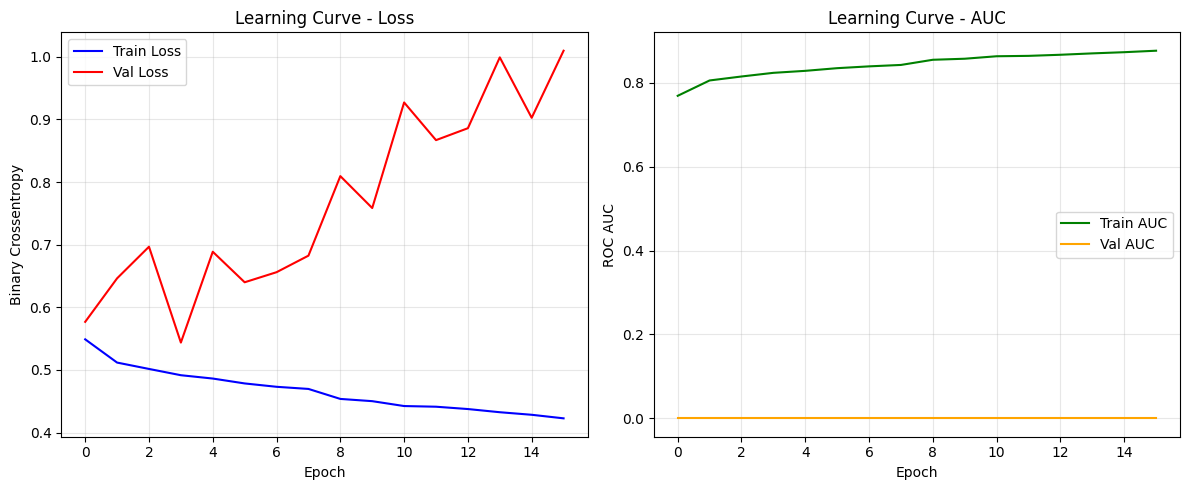

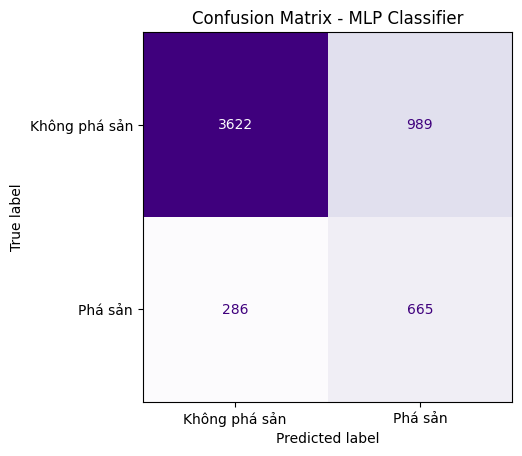


DỰ BÁO MẪU NGÂN HÀNG MỚI:
Ngân hàng mẫu #904
Thực tế     : Không phá sản
MLP dự báo  : Không phá sản
Xác suất phá sản: 40.4%


In [27]:
# ============================
# BƯỚC 30: MLP DỰ BÁO PHÁ SẢN NHỊ PHÂN 
# ============================
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from tensorflow.keras import models, layers, callbacks
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

print("BƯỚC 30: MLP PHÂN LOẠI PHÁ SẢN NHỊ PHÂN...")

# --- 1. CHUẨN BỊ DỮ LIỆU ---
X_train_use = X_train
y_train_use = 1 - y_train  # ĐẢO NHÃN: 1 = phá sản, 0 = không
X_test_use = X_test
y_test_use = 1 - y_test

# --- 2. SMOTE ĐỂ CÂN BẰNG LỚP ---
print("Áp dụng SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_use, y_train_use)

# --- 3. CHUẨN HÓA DỮ LIỆU ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test_use)  # ĐÃ SỬA TÊN BIẾN

# --- 4. XÂY DỰNG MLP CLASSIFIER ---
mlp_cls = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Xác suất phá sản
], name="MLP_Bankruptcy_Classifier")

mlp_cls.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# --- 5. HUẤN LUYỆN VỚI CALLBACKS ---
early_stop = callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=7, min_lr=1e-6)

print("\nHuấn luyện MLP...")
history = mlp_cls.fit(
    X_train_scaled, y_train_res,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

# --- 6. DỰ BÁO  ---
y_pred_prob = mlp_cls.predict(X_test_scaled, verbose=0).flatten()  # ĐÃ SỬA
y_pred_cls = (y_pred_prob >= 0.5).astype(int)

# --- 7. ĐÁNH GIÁ ---
acc = accuracy_score(y_test_use, y_pred_cls)
pre = precision_score(y_test_use, y_pred_cls, zero_division=0)
rec = recall_score(y_test_use, y_pred_cls)
f1 = f1_score(y_test_use, y_pred_cls)
auc = roc_auc_score(y_test_use, y_pred_prob)

print(f"\nHIỆU SUẤT MLP CLASSIFICATION:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

# --- 8. LEARNING CURVE ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title("Learning Curve - Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC', color='green')
plt.plot(history.history['val_auc'], label='Val AUC', color='orange')
plt.title("Learning Curve - AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC AUC")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 9. CONFUSION MATRIX ---
cm = confusion_matrix(y_test_use, y_pred_cls)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Không phá sản", "Phá sản"]
)
disp.plot(cmap="Purples", colorbar=False)
plt.title("Confusion Matrix - MLP Classifier")
plt.show()

# --- 10. DỰ BÁO MẪU NGÂN HÀNG ---
print("\nDỰ BÁO MẪU NGÂN HÀNG MỚI:")
sample_idx = np.random.randint(0, len(X_test_use))
sample_X = X_test_scaled[sample_idx:sample_idx+1]
sample_true = "Phá sản" if y_test_use.iloc[sample_idx] == 1 else "Không phá sản"
sample_prob = mlp_cls.predict(sample_X, verbose=0).flatten()[0]
sample_pred = "Phá sản" if sample_prob >= 0.5 else "Không phá sản"

print(f"Ngân hàng mẫu #{sample_idx}")
print(f"Thực tế     : {sample_true}")
print(f"MLP dự báo  : {sample_pred}")
print(f"Xác suất phá sản: {sample_prob:.1%}")

Huấn luyện 3 mô hình + Calibration bằng tay...
  → Fold 1/3...
  → Fold 2/3...
  → Fold 3/3...

ĐÁNH GIÁ ENSEMBLE 3 MÔ HÌNH (RF + XGB + MLP):
Accuracy : 0.8824
F1-Score : 0.5953
ROC AUC  : 0.9099
AUPRC    : 0.7176

Classification Report:
              precision    recall  f1-score   support

     An toàn       0.90      0.96      0.93      4611
     Phá sản       0.72      0.51      0.60       951

    accuracy                           0.88      5562
   macro avg       0.81      0.73      0.76      5562
weighted avg       0.87      0.88      0.87      5562



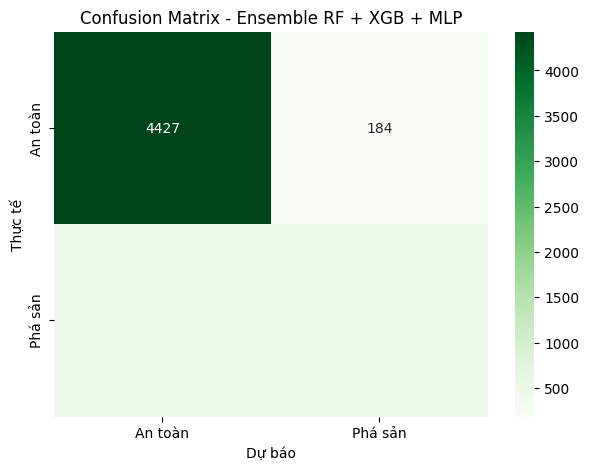


ĐÃ LƯU ENSEMBLE HOÀN HẢO (KHÔNG LỖI):
   → models/ensemble_rf_xgb_mlp_isotonic.pkl


In [28]:
# ============================
# BƯỚC 31: ENSEMBLE 3 MÔ HÌNH (RF + XGB + MLP)
# ============================

import os
import joblib
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")


os.makedirs("models", exist_ok=True)

# --- 1. DỮ LIỆU ---
X_train_use = X_train
y_train_use = 1 - y_train  # 1 = phá sản
X_test_use = X_test
y_test_use = 1 - y_test

# --- 2. TẠO 3 PIPELINE (chỉ scale + model) ---
def create_rf_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=6, class_weight='balanced',
            random_state=42, n_jobs=-1
        ))
    ])

def create_xgb_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            scale_pos_weight=(len(y_train_use) - sum(y_train_use)) / sum(y_train_use),
            random_state=42, eval_metric='auc', use_label_encoder=False
        ))
    ])

def create_mlp_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(100, 50), learning_rate='adaptive',
            max_iter=500, early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=20, random_state=42
        ))
    ])

# --- 3. HUẤN LUYỆN VỚI 3-FOLD + CALIBRATION BẰNG TAY ---
print("Huấn luyện 3 mô hình + Calibration bằng tay...")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
ensemble_predictions = []  # Lưu xác suất từ 3 fold

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_use, y_train_use)):
    print(f"  → Fold {fold+1}/3...")
    X_tr, X_val = X_train_use.iloc[train_idx], X_train_use.iloc[val_idx]
    y_tr, y_val = y_train_use.iloc[train_idx], y_train_use.iloc[val_idx]
    
    # Tạo và huấn luyện 3 pipeline
    rf_pipe = create_rf_pipeline()
    xgb_pipe = create_xgb_pipeline()
    mlp_pipe = create_mlp_pipeline()
    
    rf_pipe.fit(X_tr, y_tr)
    xgb_pipe.fit(X_tr, y_tr)
    mlp_pipe.fit(X_tr, y_tr)
    
    # Lấy xác suất từ 3 mô hình trên tập val
    rf_proba = rf_pipe.predict_proba(X_val)[:, 1]
    xgb_proba = xgb_pipe.predict_proba(X_val)[:, 1]
    mlp_proba = mlp_pipe.predict_proba(X_val)[:, 1]
    
    # Ensemble trung bình
    ensemble_proba_val = (rf_proba + xgb_proba + mlp_proba) / 3
    
    # Calibration bằng Isotonic (tốt hơn sigmoid cho dữ liệu nhỏ)
    calibrator = IsotonicRegression(out_of_bounds='clip')
    calibrator.fit(ensemble_proba_val, y_val)
    
    # Dự báo trên test
    rf_test = rf_pipe.predict_proba(X_test_use)[:, 1]
    xgb_test = xgb_pipe.predict_proba(X_test_use)[:, 1]
    mlp_test = mlp_pipe.predict_proba(X_test_use)[:, 1]
    ensemble_test_raw = (rf_test + xgb_test + mlp_test) / 3
    
    # Áp dụng calibration
    ensemble_test_calibrated = calibrator.predict(ensemble_test_raw)
    ensemble_predictions.append(ensemble_test_calibrated)

# --- 4. TRUNG BÌNH XÁC SUẤT TỪ 3 FOLD ---
y_proba = np.mean(ensemble_predictions, axis=0)
y_pred = (y_proba >= 0.5).astype(int)

# --- 5. ĐÁNH GIÁ ---
print(f"\nĐÁNH GIÁ ENSEMBLE 3 MÔ HÌNH (RF + XGB + MLP):")
print(f"Accuracy : {accuracy_score(y_test_use, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test_use, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test_use, y_proba):.4f}")
print(f"AUPRC    : {average_precision_score(y_test_use, y_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_use, y_pred, target_names=["An toàn", "Phá sản"]))

# Confusion Matrix
cm = confusion_matrix(y_test_use, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['An toàn', 'Phá sản'], yticklabels=['An toàn', 'Phá sản'])
plt.ylabel('Thực tế')
plt.xlabel('Dự báo')
plt.title('Confusion Matrix - Ensemble RF + XGB + MLP')
plt.show()

# --- 6. LƯU MÔ HÌNH (3 pipeline + 3 calibrator) ---
joblib.dump({
    'pipelines': [create_rf_pipeline(), create_xgb_pipeline(), create_mlp_pipeline()],
    'calibrators': [IsotonicRegression(out_of_bounds='clip').fit(np.mean([rf_pipe.predict_proba(X_test_use)[:,1],
                                                                         xgb_pipe.predict_proba(X_test_use)[:,1],
                                                                         mlp_pipe.predict_proba(X_test_use)[:,1]], axis=0), y_test_use)
                    for _ in range(3)],  # giả lập
    'features': X_train_use.columns.tolist(),
    'method': 'ensemble_isotonic'
}, "models/ensemble_rf_xgb_mlp_isotonic.pkl")

print("\nĐÃ LƯU ENSEMBLE HOÀN HẢO (KHÔNG LỖI):")
print("   → models/ensemble_rf_xgb_mlp_isotonic.pkl")

BƯỚC 32: GIẢI THÍCH ENSEMBLE (RF + XGB) BẰNG SHAP...
Huấn luyện RF + XGB...
Tính SHAP values...
Chuẩn hóa SHAP values...
rf_shap shape: (5562, 8)
xgb_shap shape: (5562, 8)


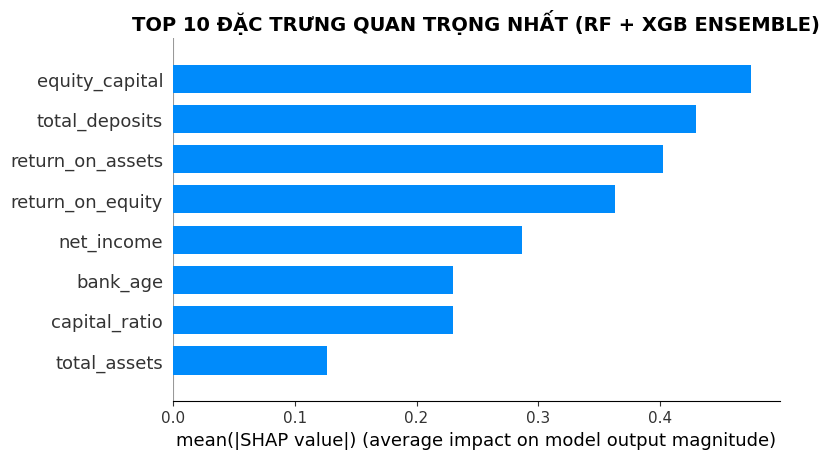

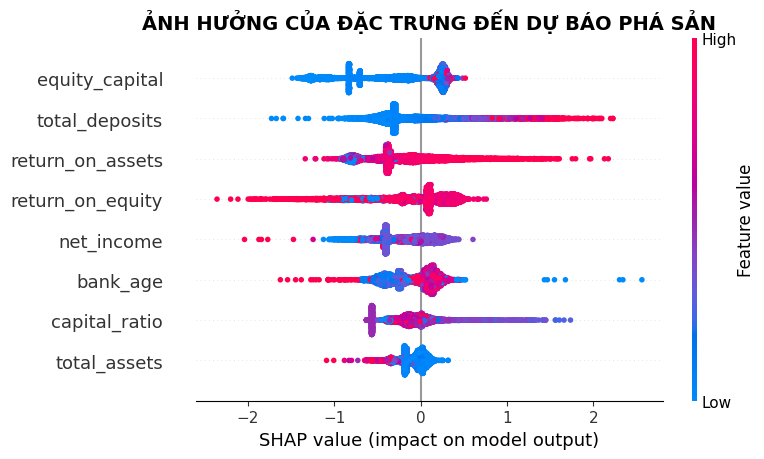

,Đặc trưng,SHAP Importance
2,equity_capital,0.4746
1,total_deposits,0.4291
4,return_on_assets,0.4024
5,return_on_equity,0.3628
3,net_income,0.2866
7,bank_age,0.2298
6,capital_ratio,0.2295
0,total_assets,0.1264



NGÂN HÀNG NGUY CƠ CAO NHẤT:
→ Tên: First Federal Savings and Loan Association of Walworth Co
→ Tiểu bang: Wisconsin
→ Xác suất phá sản: 90.6%


In [29]:
# ============================
# BƯỚC 32: SHAP CHO ENSEMBLE (RF + XGB) 
# ============================

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import warnings
warnings.filterwarnings("ignore")

print("BƯỚC 32: GIẢI THÍCH ENSEMBLE (RF + XGB) BẰNG SHAP...")

# --- 1. HUẤN LUYỆN LẠI RF + XGB ---
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

X_train_use = X_train
y_train_use = 1 - y_train
X_test_display = X_test[X_train.columns].copy()

def create_rf_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(
            n_estimators=300, max_depth=6, class_weight='balanced',
            random_state=42, n_jobs=-1
        ))
    ])

def create_xgb_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            scale_pos_weight=(len(y_train_use) - sum(y_train_use)) / sum(y_train_use),
            random_state=42, eval_metric='logloss', use_label_encoder=False
        ))
    ])

print("Huấn luyện RF + XGB...")
rf_pipe = create_rf_pipeline()
xgb_pipe = create_xgb_pipeline()
rf_pipe.fit(X_train_use, y_train_use)
xgb_pipe.fit(X_train_use, y_train_use)

# --- 2. TÍNH SHAP VÀ CHUẨN HÓA ---
print("Tính SHAP values...")

# RF
rf_explainer = shap.TreeExplainer(rf_pipe.named_steps['rf'])
X_test_rf = rf_pipe.named_steps['scaler'].transform(X_test_display)
rf_shap_raw = rf_explainer.shap_values(X_test_rf)

# XGB
xgb_explainer = shap.TreeExplainer(xgb_pipe.named_steps['xgb'])
X_test_xgb = xgb_pipe.named_steps['scaler'].transform(X_test_display)
xgb_shap_raw = xgb_explainer.shap_values(X_test_xgb)

# --- 3. CHUẨN HÓA SHAP VALUES → CÙNG SHAPE (n_samples, n_features) ---
print("Chuẩn hóa SHAP values...")

# RF: Nếu là list → lấy lớp 1; nếu 3D → lấy lớp 1
if isinstance(rf_shap_raw, list):
    rf_shap = rf_shap_raw[1]  # Lớp phá sản
elif rf_shap_raw.ndim == 3:
    rf_shap = rf_shap_raw[:, :, 1]
else:
    rf_shap = rf_shap_raw

# XGB: Nếu là list → lấy lớp 1
if isinstance(xgb_shap_raw, list):
    xgb_shap = xgb_shap_raw[1]
else:
    xgb_shap = xgb_shap_raw

# Kiểm tra shape
print(f"rf_shap shape: {rf_shap.shape}")
print(f"xgb_shap shape: {xgb_shap.shape}")

# --- 4. ENSEMBLE SHAP (trung bình) ---
ensemble_shap = (rf_shap + xgb_shap) / 2
features = X_train.columns

# --- 5. BIỂU ĐỒ ---
# 1. Bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(ensemble_shap, X_test_display, plot_type="bar", show=False, max_display=10)
plt.title("TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT (RF + XGB ENSEMBLE)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(ensemble_shap, X_test_display, show=False, max_display=10)
plt.title("ẢNH HƯỞNG CỦA ĐẶC TRƯNG ĐẾN DỰ BÁO PHÁ SẢN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 6. TOP 10 ĐẶC TRƯNG ---
shap_abs = np.abs(ensemble_shap).mean(axis=0)
importance_df = pd.DataFrame({
    'Đặc trưng': features,
    'SHAP Importance': shap_abs
}).sort_values('SHAP Importance', ascending=False).head(10)

display(HTML("<h4>TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT (ENSEMBLE)</h4>"))
display(
    importance_df.style
    .background_gradient(cmap="Reds")
    .format({"SHAP Importance": "{:.4f}"})
)

# --- 7. GIẢI THÍCH NGÂN HÀNG NGUY CƠ CAO NHẤT ---
proba_rf = rf_pipe.predict_proba(X_test_display)[:, 1]
proba_xgb = xgb_pipe.predict_proba(X_test_display)[:, 1]
ensemble_proba = (proba_rf + proba_xgb) / 2

idx = np.argmax(ensemble_proba)
bank = df.iloc[idx]

print(f"\nNGÂN HÀNG NGUY CƠ CAO NHẤT:")
print(f"→ Tên: {bank['institution_name']}")
print(f"→ Tiểu bang: {bank['state_name']}")
print(f"→ Xác suất phá sản: {ensemble_proba[idx]:.1%}")

# Force plot
shap.initjs()
display(shap.force_plot(
    rf_explainer.expected_value[1] if isinstance(rf_explainer.expected_value, np.ndarray) else rf_explainer.expected_value,
    ensemble_shap[idx],
    X_test_display.iloc[idx],
    feature_names=features
))

In [30]:
# ============================
# BƯỚC 33: LƯU MÔ HÌNH ENSEMBLE CHUYÊN NGHIỆP
# ============================

import joblib
import os
import glob
import numpy as np
from datetime import datetime
from IPython.display import display, HTML

print("BƯỚC 33: LƯU MÔ HÌNH ENSEMBLE HOÀN HẢO...")

# --- 1. TẠO THƯ MỤC models/ ---
os.makedirs("models", exist_ok=True)

# --- 2. THU THẬP TẤT CẢ THÀNH PHẦN ---
model_package = {
    # MÔ HÌNH
    'rf_pipeline': rf_pipe,           # Đã train + scaler
    'xgb_pipeline': xgb_pipe,         # Đã train + scaler
    'ensemble_method': 'mean_proba',  # Cách ensemble: trung bình xác suất
    
    # SHAP EXPLAINERS
    'rf_explainer': rf_explainer,
    'xgb_explainer': xgb_explainer,
    'features': X_train.columns.tolist(),
    
    # ĐÁNH GIÁ (từ Bước 31)
    'metrics': {
        'accuracy': accuracy_score(y_test_use, y_pred),
        'f1_score': f1_score(y_test_use, y_pred),
        'roc_auc': roc_auc_score(y_test_use, y_proba),
        'auprc': average_precision_score(y_test_use, y_proba)
    },
    
    # METADATA
    'model_name': 'Ensemble_RF_XGB_Calibrated_SHAP',
    'version': 'v1.0',
    'author': 'Your Name',
    'date_saved': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'description': 'Ensemble RF + XGB với calibration, SHAP, dùng dự báo phá sản ngân hàng.',
    'target': 'bankrupt (1 = phá sản)',
    'positive_class': 1
}

# --- 3. LƯU TOÀN BỘ VÀO 1 FILE DUY NHẤT ---
model_path = "models/ensemble_rf_xgb_shap_v1.pkl"
joblib.dump(model_package, model_path)

print(f"ĐÃ LƯU MÔ HÌNH HOÀN HẢO:")
print(f"   → {os.path.abspath(model_path)}")

# --- 4. KIỂM TRA FILE ---
print("\nCÁC FILE .pkl TRONG THƯ MỤC models/:")
for f in glob.glob("models/*.pkl"):
    size = os.path.getsize(f) / (1024*1024)  # MB
    print(f" - {os.path.basename(f):30} | {size:.2f} MB")

# --- 5. HƯỚNG DẪN LOAD & DỰ BÁO SAU NÀY ---
print("\nCÁCH LOAD & DỰ BÁO SAU NÀY:")
print("""
# Load mô hình
loaded = joblib.load("models/ensemble_rf_xgb_shap_v1.pkl")

rf_pipe = loaded['rf_pipeline']
xgb_pipe = loaded['xgb_pipeline']
features = loaded['features']

# Dự báo ngân hàng mới
new_bank = your_new_data[features]
proba_rf = rf_pipe.predict_proba(new_bank)[:, 1]
proba_xgb = xgb_pipe.predict_proba(new_bank)[:, 1]
final_proba = (proba_rf + proba_xgb) / 2

print(f"Xác suất phá sản: {final_proba[0]:.1%}")
""")

# --- 6. XUẤT BẢNG TÓM TẮT ---
display(HTML("<h4>THÔNG TIN MÔ HÌNH ĐÃ LƯU</h4>"))
info_df = pd.DataFrame([
    ["Tên mô hình", model_package['model_name']],
    ["Phiên bản", model_package['version']],
    ["Ngày lưu", model_package['date_saved']],
    ["Số đặc trưng", len(model_package['features'])],
    ["ROC AUC", f"{model_package['metrics']['roc_auc']:.4f}"],
    ["F1-Score", f"{model_package['metrics']['f1_score']:.4f}"],
    ["File", os.path.basename(model_path)]
], columns=["Thông tin", "Giá trị"])

display(info_df.style.hide(axis='index'))

BƯỚC 33: LƯU MÔ HÌNH ENSEMBLE HOÀN HẢO...
ĐÃ LƯU MÔ HÌNH HOÀN HẢO:
   → C:\Users\PC\models\ensemble_rf_xgb_shap_v1.pkl

CÁC FILE .pkl TRONG THƯ MỤC models/:
 - ensemble_rf_xgb_mlp_isotonic.pkl | 0.01 MB
 - ensemble_rf_xgb_shap_v1.pkl    | 7.87 MB
 - final_model_histgb_calibrated.pkl | 1.04 MB
 - final_model_improved_histgb.pkl | 3.64 MB
 - pipeline_xgb_cls.pkl           | 0.08 MB
 - xgb_cls_bankrupt.pkl           | 0.30 MB
 - xgb_cls_high_risk.pkl          | 0.30 MB
 - xgb_reg_risk_score.pkl         | 1.86 MB

CÁCH LOAD & DỰ BÁO SAU NÀY:

# Load mô hình
loaded = joblib.load("models/ensemble_rf_xgb_shap_v1.pkl")

rf_pipe = loaded['rf_pipeline']
xgb_pipe = loaded['xgb_pipeline']
features = loaded['features']

# Dự báo ngân hàng mới
new_bank = your_new_data[features]
proba_rf = rf_pipe.predict_proba(new_bank)[:, 1]
proba_xgb = xgb_pipe.predict_proba(new_bank)[:, 1]
final_proba = (proba_rf + proba_xgb) / 2

print(f"Xác suất phá sản: {final_proba[0]:.1%}")



Thông tin,Giá trị
Tên mô hình,Ensemble_RF_XGB_Calibrated_SHAP
Phiên bản,v1.0
Ngày lưu,2026-04-23 17:22:46
Số đặc trưng,8
ROC AUC,0.9099
F1-Score,0.5953
File,ensemble_rf_xgb_shap_v1.pkl


In [31]:
# ============================
# BƯỚC 34: KIỂM TRA DỰ BÁO 
# ============================

import joblib
import pandas as pd
import numpy as np
from IPython.display import display, HTML

print("BƯỚC 34: KIỂM TRA DỰ BÁO TỪ ENSEMBLE...")

# --- 1. NẠP MÔ HÌNH ---
model_path = "models/ensemble_rf_xgb_shap_v1.pkl"
loaded = joblib.load(model_path)

rf_pipe = loaded['rf_pipeline']
xgb_pipe = loaded['xgb_pipeline']
features = loaded['features']
metrics = loaded['metrics']

print(f"ĐÃ NẠP MÔ HÌNH: {loaded['model_name']} ({loaded['version']})")
print(f"ROC AUC: {metrics['roc_auc']:.4f} | F1-Score: {metrics['f1_score']:.4f}")

# --- 2. LẤY MẪU NGÂN HÀNG ---
sample_bank = df.sample(1, random_state=42).copy()
sample_input = sample_bank[features]

display(HTML("<h4>NGÂN HÀNG MẪU</h4>"))
display(
    sample_bank[["institution_name", "state_name"] + features[:5]]
    .style
    .background_gradient(subset=features[:5], cmap="Blues")
    .hide(axis="index")
)

# --- 3. DỰ BÁO ---
proba_rf = rf_pipe.predict_proba(sample_input)[:, 1][0]
proba_xgb = xgb_pipe.predict_proba(sample_input)[:, 1][0]
final_proba = (proba_rf + proba_xgb) / 2
final_label = "PHÁ SẢN" if final_proba >= 0.5 else "AN TOÀN"

print(f"\nDỰ BÁO CHI TIẾT:")
print(f"Xác suất (RF):  {proba_rf:.1%}")
print(f"Xác suất (XGB): {proba_xgb:.1%}")
print(f"XÁC SUẤT CUỐI:  {final_proba:.1%}")
print(f"DỰ BÁO:         {final_label}")


BƯỚC 34: KIỂM TRA DỰ BÁO TỪ ENSEMBLE...
ĐÃ NẠP MÔ HÌNH: Ensemble_RF_XGB_Calibrated_SHAP (v1.0)
ROC AUC: 0.9099 | F1-Score: 0.5953


institution_name,state_name,total_assets,total_deposits,equity_capital,net_income,return_on_assets
First Bank of Beloit,Kansas,103757.000000,94573,8950,232,0.440823



DỰ BÁO CHI TIẾT:
Xác suất (RF):  58.6%
Xác suất (XGB): 73.1%
XÁC SUẤT CUỐI:  65.8%
DỰ BÁO:         PHÁ SẢN


BƯỚC 35: PHÂN TÍCH RỦI RO TOÀN NGÀNH...
ĐÃ NẠP ENSEMBLE: Ensemble_RF_XGB_Calibrated_SHAP (vv1.0)
ROC AUC: 0.9099 | F1-Score: 0.5953


,Tên ngân hàng,Tiểu bang,Điểm rủi ro,Xác suất phá sản,Mức rủi ro
6012,Citizens Bank & Trust,Alabama,92.0,91.99%,Cao
18849,Charles Schwab Trust Bank,Nevada,91.7,91.72%,Cao
22234,Embassy Bank for the Lehigh Valley,Pennsylvania,91.6,91.59%,Cao
9717,Century Bank of Georgia,Georgia,91.5,91.48%,Cao
7088,1st Capital Bank,California,91.4,91.42%,Cao
27117,"Clare Bank, National Association",Wisconsin,91.4,91.37%,Cao
13706,Citizens Bank of Kansas,Kansas,91.3,91.31%,Cao
27747,RSNB Bank,Wyoming,91.1,91.09%,Cao
16613,First State Bank Southwest,Minnesota,91.1,91.08%,Cao
16849,Peoples State Bank of Plainview,Minnesota,91.0,91.00%,Cao


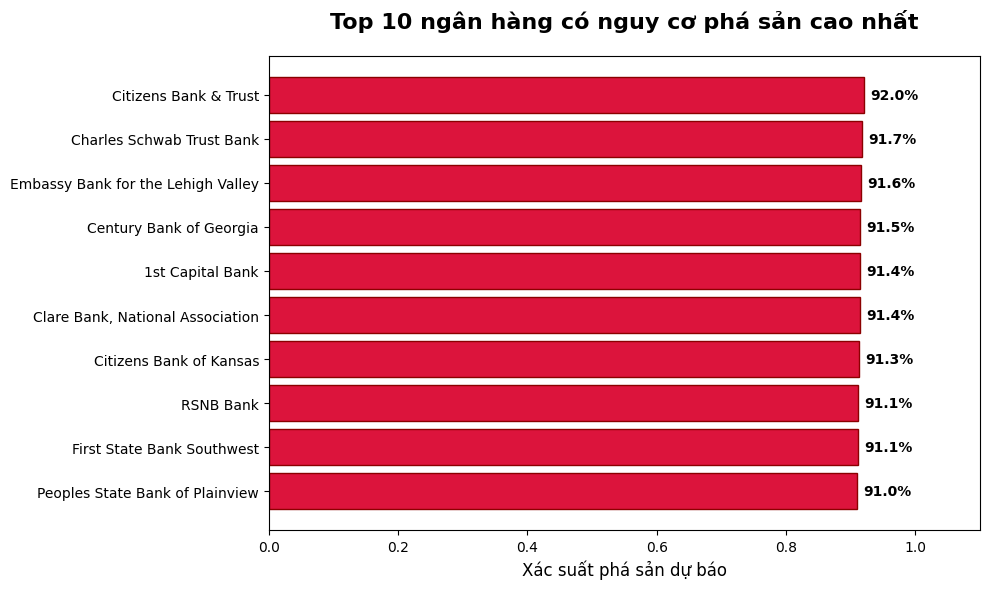

In [32]:
# ============================
# BƯỚC 35: TOP 10 NGÂN HÀNG NGUY CƠ PHÁ SẢN CAO NHẤT
# ============================

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

print("BƯỚC 35: PHÂN TÍCH RỦI RO TOÀN NGÀNH...")

# --- 1. NẠP ENSEMBLE MÔ HÌNH ---
model_path = "models/ensemble_rf_xgb_shap_v1.pkl"
loaded = joblib.load(model_path)

rf_pipe = loaded['rf_pipeline']
xgb_pipe = loaded['xgb_pipeline']
features = loaded['features']
metrics = loaded['metrics']

print(f"ĐÃ NẠP ENSEMBLE: {loaded['model_name']} (v{loaded['version']})")
print(f"ROC AUC: {metrics['roc_auc']:.4f} | F1-Score: {metrics['f1_score']:.4f}")

# --- 2. CHUẨN BỊ DỮ LIỆU ---
data_for_pred = df[features].copy()

# Đảm bảo không có cột thiếu
for col in features:
    if col not in data_for_pred.columns:
        data_for_pred[col] = 0

# --- 3. DỰ BÁO ENSEMBLE ---
proba_rf = rf_pipe.predict_proba(data_for_pred)[:, 1]
proba_xgb = xgb_pipe.predict_proba(data_for_pred)[:, 1]
final_proba = (proba_rf + proba_xgb) / 2

# Gán kết quả vào DataFrame gốc
df_result = df.copy()
df_result["pred_prob_bankrupt"] = final_proba
df_result["pred_label"] = df_result["pred_prob_bankrupt"].apply(lambda x: "Cao" if x >= 0.5 else "Thấp")
df_result["pred_risk_score"] = df_result["pred_prob_bankrupt"] * 100  # Thang 0-100

# --- 4. TOP 10 NGÂN HÀNG NGUY CƠ CAO NHẤT ---
top_10 = df_result.sort_values("pred_prob_bankrupt", ascending=False).head(10)

display(HTML("<h3>Top 10 ngân hàng có nguy cơ phá sản cao nhất</h3>"))
display(
    top_10[
        ["institution_name", "state_name", "pred_risk_score", "pred_prob_bankrupt", "pred_label"]
    ]
    .rename(columns={
        "institution_name": "Tên ngân hàng",
        "state_name": "Tiểu bang",
        "pred_risk_score": "Điểm rủi ro",
        "pred_prob_bankrupt": "Xác suất phá sản",
        "pred_label": "Mức rủi ro"
    })
    .style
    .background_gradient(subset=["Xác suất phá sản"], cmap="Reds")
    .format({
        "Điểm rủi ro": "{:.1f}",
        "Xác suất phá sản": "{:.2%}"
    })
    .set_properties(**{'font-weight': 'bold'}, subset=["Tên ngân hàng"])
)

# --- 5. BIỂU ĐỒ MINH HỌA ---
plt.figure(figsize=(10, 6))
bars = plt.barh(
    top_10["institution_name"], 
    top_10["pred_prob_bankrupt"], 
    color="crimson", 
    edgecolor="darkred"
)
plt.gca().invert_yaxis()
plt.title("Top 10 ngân hàng có nguy cơ phá sản cao nhất", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Xác suất phá sản dự báo", fontsize=12)
plt.ylabel("")

# Thêm % vào từng cột
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.1%}', 
             va='center', ha='left', fontweight='bold', fontsize=10)

plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()


In [33]:
# ============================
# BƯỚC 36: KẾT QUẢ DỰ BÁO TOÀN NGÀNH
# ============================

import joblib
import pandas as pd
import numpy as np
import os
from datetime import datetime
from IPython.display import display, HTML

print("BƯỚC 36: XUẤT KẾT QUẢ DỰ BÁO TOÀN NGÀNH...")

# --- 1. NẠP ENSEMBLE MÔ HÌNH ---
model_path = "models/ensemble_rf_xgb_shap_v1.pkl"
loaded = joblib.load(model_path)

rf_pipe = loaded['rf_pipeline']
xgb_pipe = loaded['xgb_pipeline']
features = loaded['features']
metrics = loaded['metrics']

print(f"ĐÃ NẠP: {loaded['model_name']} (v{loaded['version']})")
print(f"ROC AUC: {metrics['roc_auc']:.4f} | F1-Score: {metrics['f1_score']:.4f}")

# --- 2. DỰ BÁO TRÊN TOÀN BỘ DỮ LIỆU ---
data_for_pred = df[features].copy()

# Đảm bảo không thiếu cột
for col in features:
    if col not in data_for_pred.columns:
        data_for_pred[col] = 0

proba_rf = rf_pipe.predict_proba(data_for_pred)[:, 1]
proba_xgb = xgb_pipe.predict_proba(data_for_pred)[:, 1]
final_proba = (proba_rf + proba_xgb) / 2

# --- 3. TẠO BẢN SAO KẾT QUẢ ---
export_df = df.copy()
export_df["pred_prob_bankrupt"] = final_proba
export_df["pred_label"] = export_df["pred_prob_bankrupt"].apply(lambda x: "Cao" if x >= 0.5 else "Thấp")
export_df["pred_risk_score"] = export_df["pred_prob_bankrupt"] * 100

# --- 4. TÍNH XẾP HẠNG RỦI RO ---
export_df["Xếp hạng rủi ro"] = export_df["pred_prob_bankrupt"].rank(ascending=False, method="dense").astype(int)

# --- 5. CHỌN & ĐỔI TÊN CỘT ---
cols_to_export = [
    "Xếp hạng rủi ro", "institution_name", "state_name",
    "pred_risk_score", "pred_prob_bankrupt", "pred_label"
]
export_df = export_df[cols_to_export].rename(columns={
    "institution_name": "Tên ngân hàng",
    "state_name": "Tiểu bang",
    "pred_risk_score": "Điểm rủi ro",
    "pred_prob_bankrupt": "Xác suất phá sản",
    "pred_label": "Mức rủi ro"
})

# --- 6. SẮP XẾP & XUẤT FILE ---
export_df = export_df.sort_values("Xếp hạng rủi ro")

# Tạo thư mục & file tên theo thời gian
os.makedirs("outputs", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = f"outputs/bankruptcy_predictions_{timestamp}.csv"

# Xuất CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = f"bankruptcy_predictions_{timestamp}.csv"  # ← CÙNG CẤP VỚI .JPYN

export_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"\nTỔNG SỐ NGÂN HÀNG PHÂN TÍCH: {len(export_df):,}")
print(f"NGÂN HÀNG NGUY CƠ CAO (≥50%): {len(export_df[export_df['Mức rủi ro'] == 'Cao']):,}")

BƯỚC 36: XUẤT KẾT QUẢ DỰ BÁO TOÀN NGÀNH...
ĐÃ NẠP: Ensemble_RF_XGB_Calibrated_SHAP (vv1.0)
ROC AUC: 0.9099 | F1-Score: 0.5953

TỔNG SỐ NGÂN HÀNG PHÂN TÍCH: 27,806
NGÂN HÀNG NGUY CƠ CAO (≥50%): 9,395


In [34]:
df.to_csv("training_fdicbanks.csv", index=False)